# AI Governance-Linked Dynamic Insurance Premium — Simulation Notebook

**Research Project**: Governance-Based Dynamic Pricing for High-Impact AI Liability Insurance  
**Submitted to**: Samsung Fire & Marine Insurance Risk Management Competition  

---

## Notebook Overview

This notebook implements the end-to-end insurance premium simulation described in the paper.
It covers four main sections:

| # | Section | Purpose |
|---|---|---|
| 1 | **Libraries & Hyperparameters** | Import packages; set actuarially grounded constants |
| 2 | **Domain & Scenario Definition** | Define 7 AI application domains and 4 governance scenarios (Type A–D) |
| 3 | **Monte Carlo Simulation** | Compute aggregate loss distribution and premium by scenario × domain |
| 4 | **Real Data Validation** | Apply the model to actual AIID incidents for empirical cross-check |
| 5 | **Sensitivity Analysis** | One-at-a-time (OAT) perturbation of 5 actuarial hyperparameters + λ-source variant |

### Core Loss Model

$$E[L \mid G] = \lambda(G) \cdot \mu$$

where

$$\lambda(G) = \lambda_{\text{global}} \cdot e^{-\gamma \, G_{\text{ops}}}$$

### Premium Formula

$$\pi(G) = \frac{\bigl(E[L] + \phi \cdot \text{TVaR}_{99}\bigr)(1+\theta)}{1 - e}$$

| Symbol | Meaning | Value / Source |
|--------|---------|----------------|
| $\sigma$ | Log-normal shape parameter | 4.351 — AIID 183-record dataset |
| $\gamma$ | Frequency decay coefficient | 1.314 — Munich Re Cyber 2024 |
| $\phi$ | TVaR loading weight | 0.15 — Solvency II / Artzner et al. (1999) |
| $\theta$ | Risk margin | 0.25 — Munich Re Cyber Outlook 2024 |
| $e$ | Expense ratio | 0.30 — FSS Korea + Lloyd's |


In [1]:
#Import Packages

import os
import numpy as np
import pandas as pd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ─────────────────────────────────────────────
# Font: 삼성긴고딕OTF (7 weights, family = SamsungGothicCondensedOTF)
# ─────────────────────────────────────────────
# The OTF file's family-name field (Win 3,1 en) is "SamsungGothicCondensedOTF <Weight>",
# but matplotlib reads name-ID 16 (typographic family) which is the unified
# "SamsungGothicCondensedOTF". Registering all 7 weights lets matplotlib pick
# the right one automatically based on font.weight.
_SG_DIR = os.path.expanduser('~/Library/Fonts')
for _w in ['UltraLight', 'Light', 'Regular', 'Medium', 'Bold', 'ExtraBold', 'Heavy']:
    _fp = os.path.join(_SG_DIR, f'삼성긴고딕 {_w}.otf')
    if os.path.exists(_fp):
        fm.fontManager.addfont(_fp)
_SG_FAMILY = 'SamsungGothicCondensedOTF'

plt.rcParams.update({
        "font.family": _SG_FAMILY,
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.labelpad": 10,
        "axes.titlepad": 15,
        "axes.unicode_minus": False,
    })

import os
os.makedirs('figures', exist_ok=True)

from matplotlib.colors import LinearSegmentedColormap
colors = [
    '#5BC2E7', '#003CDC', '#FED63F', '#B4CF3C',
    '#3AAD67', '#F39945', '#F2A4BC', '#F96D69'
]

# ─────────────────────────────────────────────
# Hyperparamter Settings
# ─────────────────────────────────────────────
SIGMA = 4.351   # Log-normal shape; cross-validated at 4.329 on AIID 183-record subset
GAMMA = 1.314   # Frequency decay coeff.; derived from Munich Re 2024 cyber (30–50% reduction)
PHI   = 0.15    # TVaR loading weight — Solvency II / Artzner et al. (1999)
THETA = 0.25    # Risk margin — Munich Re Cyber Outlook (2024)
EXP_RATIO = 0.30  # Expense ratio — FSS Korea + Lloyd's specialty market
N_SIM = 100_000   # Monte Carlo iterations (increased from 50K for convergence)

## Section 1 — Libraries and Hyperparameters

All hyperparameters are derived from peer-reviewed literature or
industry benchmark reports; sources are cited inline.


In [2]:
# The block below (commented out) shows the global-weight version.
# Active version uses domain-specific weights loaded from CSV.
'''W = {'D': 0.108, 'Q': 0.155, 'T': 0.156, 'H': 0.117, 'M': 0.116, 'R': 0.130, 'C': 0.133, 'S': 0.085} # Global weights (no domain split)

DOMAIN_WEIGHTS = { # Domain-specific weights
    'Public Administration':  {'D': 0.129, 'Q': 0.152, 'T': 0.152, 'H': 0.114, 'M': 0.083, 'R': 0.129, 'C': 0.144, 'S': 0.098},
    'Education':       {'D': 0.134, 'Q': 0.134, 'T': 0.146, 'H': 0.146, 'M': 0.110, 'R': 0.110, 'C': 0.134, 'S': 0.085},
    'Financial Services':       {'D': 0.091, 'Q': 0.152, 'T': 0.152, 'H': 0.121, 'M': 0.121, 'R': 0.121, 'C': 0.152, 'S': 0.091},
    'Robotics':      {'D': 0.070, 'Q': 0.163, 'T': 0.174, 'H': 0.105, 'M': 0.128, 'R': 0.128, 'C': 0.151, 'S': 0.081},
    'Medical AI': {'D': 0.129, 'Q': 0.151, 'T': 0.140, 'H': 0.108, 'M': 0.129, 'R': 0.129, 'C': 0.140, 'S': 0.075},
    'Autonomous Vehicle':         {'D': 0.070, 'Q': 0.172, 'T': 0.172, 'H': 0.130, 'M': 0.130, 'R': 0.135, 'C': 0.126, 'S': 0.065},
    'Recruitment / Hiring':       {'D': 0.098, 'Q': 0.171, 'T': 0.171, 'H': 0.098, 'M': 0.106, 'R': 0.122, 'C': 0.146, 'S': 0.089},
    'Others':       {'D': 0.120, 'Q': 0.149, 'T': 0.149, 'H': 0.116, 'M': 0.118, 'R': 0.134, 'C': 0.125, 'S': 0.089}
}
'''
SCENARIOS = {
    'Type A': {'D':0.25,'Q':0.00,'T':0.25,'H':0.00,'M':0.00,'R':0.00,'C':0.25,'S':0.00},
    'Type B': {'D':0.50,'Q':0.50,'T':0.50,'H':0.25,'M':0.25,'R':0.25,'C':0.50,'S':0.25},
    'Type C': {'D':0.75,'Q':0.75,'T':0.75,'H':0.75,'M':0.75,'R':0.50,'C':0.75,'S':0.75},
    'Type D': {'D':1.00,'Q':1.00,'T':1.00,'H':1.00,'M':1.00,'R':0.75,'C':1.00,'S':1.00},
}
weights_df = pd.read_csv("aiid_domain_and_general_weights.csv", index_col=0)

DOMAIN_WEIGHTS = weights_df.to_dict(orient='index')
W = DOMAIN_WEIGHTS["General"]
N_MAP = {'Type A':30, 'Type B':50, 'Type C':150, 'Type D':400}

DOMAINS = {
    'Medical AI': {
        'mu_USD':         9_770_000,    # IBM Healthcare 2024 (14-year #1 industry)
        'lambda_global':  5,             # AIID 0.4 + FDA AI device adoption adj. (Grade B)
        'D_pop':          800_000_000,   # Global digital health (Teladoc 100M + others)
        'grade':          'B',  # λ data quality grade
        'mu_source':      'IBM Cost of Data Breach 2024 - Healthcare $9.77M',
        'lambda_source':  'AIID 5-year 0.4 incidents + FDA AI device 1,451-unit adoption adjustment',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. ra (Medical Devices)',
    },
    'Autonomous Vehicle': {
        'mu_USD':         4_370_000,     # IBM Transportation 2024
        'lambda_global':  5,             # AIID 1.0 + Tesla/Cruise case supplement (Grade B)
        'D_pop':          50_000_000,    # Tesla L2 8.8M + Waymo + China + others
        'grade':          'B',  # λ data quality grade
        'mu_source':      'IBM Cost of Data Breach 2024 - Transportation $4.37M',
        'lambda_source':  'AIID 5-year 5 incidents (AV + mobility) + Tesla trial / Cruise cases',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. ah (Transportation)',
    },
    'Robotics': {
        'mu_USD':         5_560_000,     # IBM Industrial 2024
        'lambda_global':  5,             # Korea 1/yr × global market-share adjustment (Grade C)
        'D_pop':          14_000_000,    # IFR 4.66M units × 3 workers/unit
        'grade':          'C',
        'mu_source':      'IBM Cost of Data Breach 2024 - Industrial $5.56M',
        'lambda_source':  'AIID 5-yr 0 (under-reported) + Korea industrial safety 1/yr x5 global',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. cha (Industrial Safety)',
    },
    'Financial Services': {
        'mu_USD':         6_080_000,     # IBM Financial 2024
        'lambda_global':  16,            # AIID 5-yr 78 incidents = 15.6/yr (observed, Grade A)
        'D_pop':          3_000_000_000, # Global digital banking (World Bank Findex 2024)
        'grade':          'A',
        'mu_source':      'IBM Cost of Data Breach 2024 - Financial $6.08M',
        'lambda_source':  'AIID direct count: 78 incidents over 5 years (observed)',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. sa (Loan Assessment)',
    },
    'Recruitment / Hiring': {
        'mu_USD':         4_970_000,     # IBM Tech 2024 (HR-tech classification)
        'lambda_global':  5,             # AIID 0.2 + EEOC + Workday + GDPR supplement (Grade C)
        'D_pop':          800_000_000,   # LinkedIn 310M + Indeed + Glassdoor
        'grade':          'C',
        'mu_source':      'IBM Cost of Data Breach 2024 - Technology $4.97M',
        'lambda_source':  'AIID 5-year 1 incident + EEOC iTutor + Workday + CVS HireVue',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. sa (Hiring / Dismissal)',
    },
    'Public Administration': {
        'mu_USD':         2_550_000,     # IBM Public Sector 2024
        'lambda_global':  6,             # AIID 5-yr 29 incidents = 5.8/yr (observed, Grade A)
        'D_pop':          3_000_000_000, # UN E-Government Survey 2024 — global public services
        'grade':          'A',
        'mu_source':      'IBM Cost of Data Breach 2024 - Public Sector $2.55M',
        'lambda_source':  'AIID direct count: 29 incidents over 5 years (observed)',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. ja (Public Services)',
    },
    'Education': {
        'mu_USD':         3_860_000,     # IBM Education 2024
        'lambda_global':  3,             # AIID 5-yr 12 incidents = 2.4/yr (observed, Grade A)
        'D_pop':          500_000_000,   # Duolingo 130M + Coursera + Khan + others
        'grade':          'A',
        'mu_source':      'IBM Cost of Data Breach 2024 - Education $3.86M',
        'lambda_source':  'AIID direct count: 12 incidents over 5 years (observed)',
        'ai_basic_act_clause':     'Korea AI Basic Act — Art. cha (K-12 Education)',
    },
}

for dom in DOMAINS:
    DOMAINS[dom]['weights'] = DOMAIN_WEIGHTS.get(dom, W)

print("\n[ 7 Industry Domains — Global Parameters (IBM + AIID) ]")
print(f"{'Industry':<14}{'μ (USD)':>14}{'λ/yr':>7}{'D_pop':>17}{'Grade':>5}")
for d, p in DOMAINS.items():
    print(f"{d:<14}${p['mu_USD']:>13,}{p['lambda_global']:>7}"
          f"{p['D_pop']:>17,}{p['grade']:>5}")


[ 7 Industry Domains — Global Parameters (IBM + AIID) ]
Industry             μ (USD)   λ/yr            D_popGrade
Medical AI    $    9,770,000      5      800,000,000    B
Autonomous Vehicle$    4,370,000      5       50,000,000    B
Robotics      $    5,560,000      5       14,000,000    C
Financial Services$    6,080,000     16    3,000,000,000    A
Recruitment / Hiring$    4,970,000      5      800,000,000    C
Public Administration$    2,550,000      6    3,000,000,000    A
Education     $    3,860,000      3      500,000,000    A


## Section 2 — Domain and Scenario Definition

### Governance Scenarios (Type A – D)

Each scenario represents a distinct AI governance maturity level,
mapped to the eight controls (D/Q/T/H/M/R/C/S) defined in the
governance framework.

| Type | Label | Description |
|------|-------|-------------|
| **A** | No governance | Controls largely absent; minimal documentation |
| **B** | Basic policy | Written policies exist; partial implementation |
| **C** | Operational | Controls regularly operated and logged |
| **D** | Certified | Automated, auditable, continuously improved |

### Domain Parameters

- **μ (mu_USD)** — average loss per incident; source: IBM Cost of Data Breach 2024  
- **λ (lambda_global)** — annual incident frequency; source: AIID direct count or expert adjustment  
- **D_pop** — exposed population size; source: industry-specific public statistics  


In [3]:
# ─────────────────────────────────────────────
# Governance Operation Score
# ─────────────────────────────────────────────

def calc_G_ops(sic): # apply global weights
    return sum(W[c] * sic[c] for c in W)

def calc_G_ops_custom(sic, weights): # apply domain-specific weights
    return sum(weights[c] * sic.get(c, 0) for c in weights)

G_ops_scores = {k: calc_G_ops(v) for k, v in SCENARIOS.items()} # governance score

print("\n[ Governance Operation Score (G_ops) ]")
for typ in SCENARIOS:
    print(f"  {typ}: G_ops={G_ops_scores[typ]:.4f}")

# ─────────────────────────────────────────────
# Monte Carlo Simulation
# ─────────────────────────────────────────────
def calc_loss_distribution(lam, mu_eff, sigma, n_sim=N_SIM, pct=99):
    """
      N ~ Poisson(λ_industry)
      X_i ~ Lognormal(log(mu_eff) - σ²/2, σ)
      L = Σ X_i
    Returns: E[L], TVaR99
    """
    mu_log = np.log(mu_eff) - sigma**2 / 2
    losses = np.zeros(n_sim)
    for b in range(n_sim):
        n_acc = np.random.poisson(lam)
        if n_acc > 0:
            sev = np.random.lognormal(mu_log, sigma, n_acc)
            losses[b] = sev.sum()
    EL = losses.mean()
    var = np.percentile(losses, pct)
    tail = losses[losses >= var]
    tvar = tail.mean() if len(tail) > 0 else var
    return EL, tvar

# ─────────────────────────────────────────────
# Premium Calculation
# ─────────────────────────────────────────────
print("\n" + "=" * 80)
print("[ Insurance Premium Calculation ]")
print("=" * 80)
print(f"  Monte Carlo n_sim = {N_SIM:,}")

'''
# --- Alternative: global-weight version (commented out) ---
results = []
for typ, sic in SCENARIOS.items():
    G_ops = G_ops_scores[typ]
    n_samp = N_MAP[typ]
    #I_val = exp_results[n_samp]['I_norm']

    for dom, p in DOMAINS.items():
        DOMAINS[dom]['weights'] = DOMAIN_WEIGHTS.get(dom, W_DEFAULT)
        lam_final = p['lambda_global'] * np.exp(-GAMMA * G_ops)
        #mu_eff = p['mu_USD'] * g_G[typ]
        mu_eff = p['mu_USD']

        EL, tvar = calc_loss_distribution(lam_final, mu_eff, SIGMA)
        #EL, tvar = calc_loss_distribution(lam_final, mu_eff, SIGMA)
        pi = (EL + PHI * tvar) * (1 + THETA) / (1 - EXP_RATIO)

        results.append({
            'Type': typ, 'Domain': dom, 'grade': p['grade'],
            'G_ops': G_ops, 'lambda_global': p['lambda_global'],
            'lambda_final': lam_final,
            #'I': I_val, 
            'g(G)': g_G[typ],
            'mu_USD': p['mu_USD'], 'mu_eff_USD': mu_eff,
            'E[L]_USD': EL, 'TVaR99_USD': tvar,
            'Premium_USD': pi,
            'Per_capita_USD': pi / p['D_pop'],
            'Per_capita_KRW': pi / p['D_pop'] * 1380,
        })
'''
results = []
for typ, sic in SCENARIOS.items():
    for dom, p in DOMAINS.items():
        # KEY: retrieve domain-specific weights and compute G_ops
        current_weights = p['weights']
        G_ops = calc_G_ops_custom(sic, current_weights)
        
        # frequency decay: λ_final = λ_global × exp(-γ × G_ops)
        lam_final = p['lambda_global'] * np.exp(-GAMMA * G_ops)
        mu_eff = p['mu_USD']

        EL, tvar = calc_loss_distribution(lam_final, mu_eff, SIGMA)
        pi = (EL + PHI * tvar) * (1 + THETA) / (1 - EXP_RATIO)

        results.append({
            'Type': typ, 'Domain': dom, 'grade': p['grade'],
            'G_ops': G_ops, 'lambda_global': p['lambda_global'],
            'lambda_final': lam_final,
            'mu_USD': p['mu_USD'], 'mu_eff_USD': mu_eff,
            'E[L]_USD': EL, 'TVaR99_USD': tvar,
            'Premium_USD': pi,
            'Per_capita_USD': pi / p['D_pop'],
            'Per_capita_KRW': pi / p['D_pop'] * 1380,
        })
        
df = pd.DataFrame(results)
type_order = ['Type A','Type B','Type C','Type D']
domain_order = list(DOMAINS.keys())

piv_pi  = df.pivot(index='Type', columns='Domain', values='Premium_USD').reindex(type_order)[domain_order]
piv_rel = piv_pi.div(piv_pi.loc['Type A'], axis=1)
piv_pc  = df.pivot(index='Type', columns='Domain', values='Per_capita_USD').reindex(type_order)[domain_order]
piv_pc_KRW = df.pivot(index='Type', columns='Domain', values='Per_capita_KRW').reindex(type_order)[domain_order]

print("\n[ Absolute Premium (USD, industry-wide annual) ]")
print(piv_pi.map(lambda x: f"${x:>16,.0f}").to_string())

print("\n[ Premium Relativity (vs. Type A) ]")
print(piv_rel.round(4).to_string())

avg_rel = piv_rel.mean(axis=1)
print("\n[ Average Premium Relativity ]")
for typ, val in avg_rel.items():
    print(f"  {typ}: {val:.4f}")

# Grade-A domains only (higher data reliability)
grade_a_doms = [d for d in domain_order if DOMAINS[d]['grade'] == 'A']
piv_rel_a = piv_rel[grade_a_doms]
avg_rel_a = piv_rel_a.mean(axis=1)
print("\n[ Average Relativity — Grade-A Domains Only (higher reliability) ]")
print(f"  Target domains: {grade_a_doms}")
for typ, val in avg_rel_a.items():
    print(f"  {typ}: {val:.4f}")

print("\n[ Per-Capita Annual Premium (USD/year) ]")
print(piv_pc.map(lambda x: f"${x:>10.4f}").to_string())

print("\n[ Per-Capita Annual Premium (KRW/year, rate 1,380) ]")
print(piv_pc_KRW.map(lambda x: f"{x:>10,.1f}").to_string())



[ Governance Operation Score (G_ops) ]
  Type A: G_ops=0.0992
  Type B: G_ops=0.3880
  Type C: G_ops=0.7175
  Type D: G_ops=0.9675

[ Insurance Premium Calculation ]
  Monte Carlo n_sim = 100,000



[ Absolute Premium (USD, industry-wide annual) ]
Domain         Medical AI Autonomous Vehicle           Robotics Financial Services Recruitment / Hiring Public Administration          Education
Type                                                                                                                                            
Type A  $     701,844,281  $     257,299,674  $     384,321,214  $   8,138,937,372    $     468,172,486     $     215,759,679  $     209,702,156
Type B  $   1,183,148,506  $     262,296,536  $     410,751,466  $     962,038,344    $     271,490,896     $     150,840,862  $     150,237,145
Type C  $     436,275,836  $     155,162,448  $     234,975,086  $   1,149,469,174    $     348,755,558     $      82,093,768  $      91,134,017
Type D  $     145,692,160  $     115,624,295  $     151,081,607  $     693,109,087    $      85,126,183     $      69,897,562  $     112,736,185

[ Premium Relativity (vs. Type A) ]
Domain  Medical AI  Autonomous Vehicle  Rob

## Section 3 — Monte Carlo Simulation

For each scenario × domain combination, the aggregate annual loss is
simulated as a compound Poisson process:

$$L = \sum_{i=1}^{N} X_i, \quad N \sim \text{Poisson}(\lambda_\text{final}),\ X_i \sim \text{LogNormal}\left(\log \mu - \tfrac{\sigma^2}{2},\ \sigma\right)$$

The premium is then computed from the simulated $E[L]$ and $\text{TVaR}_{99}$.


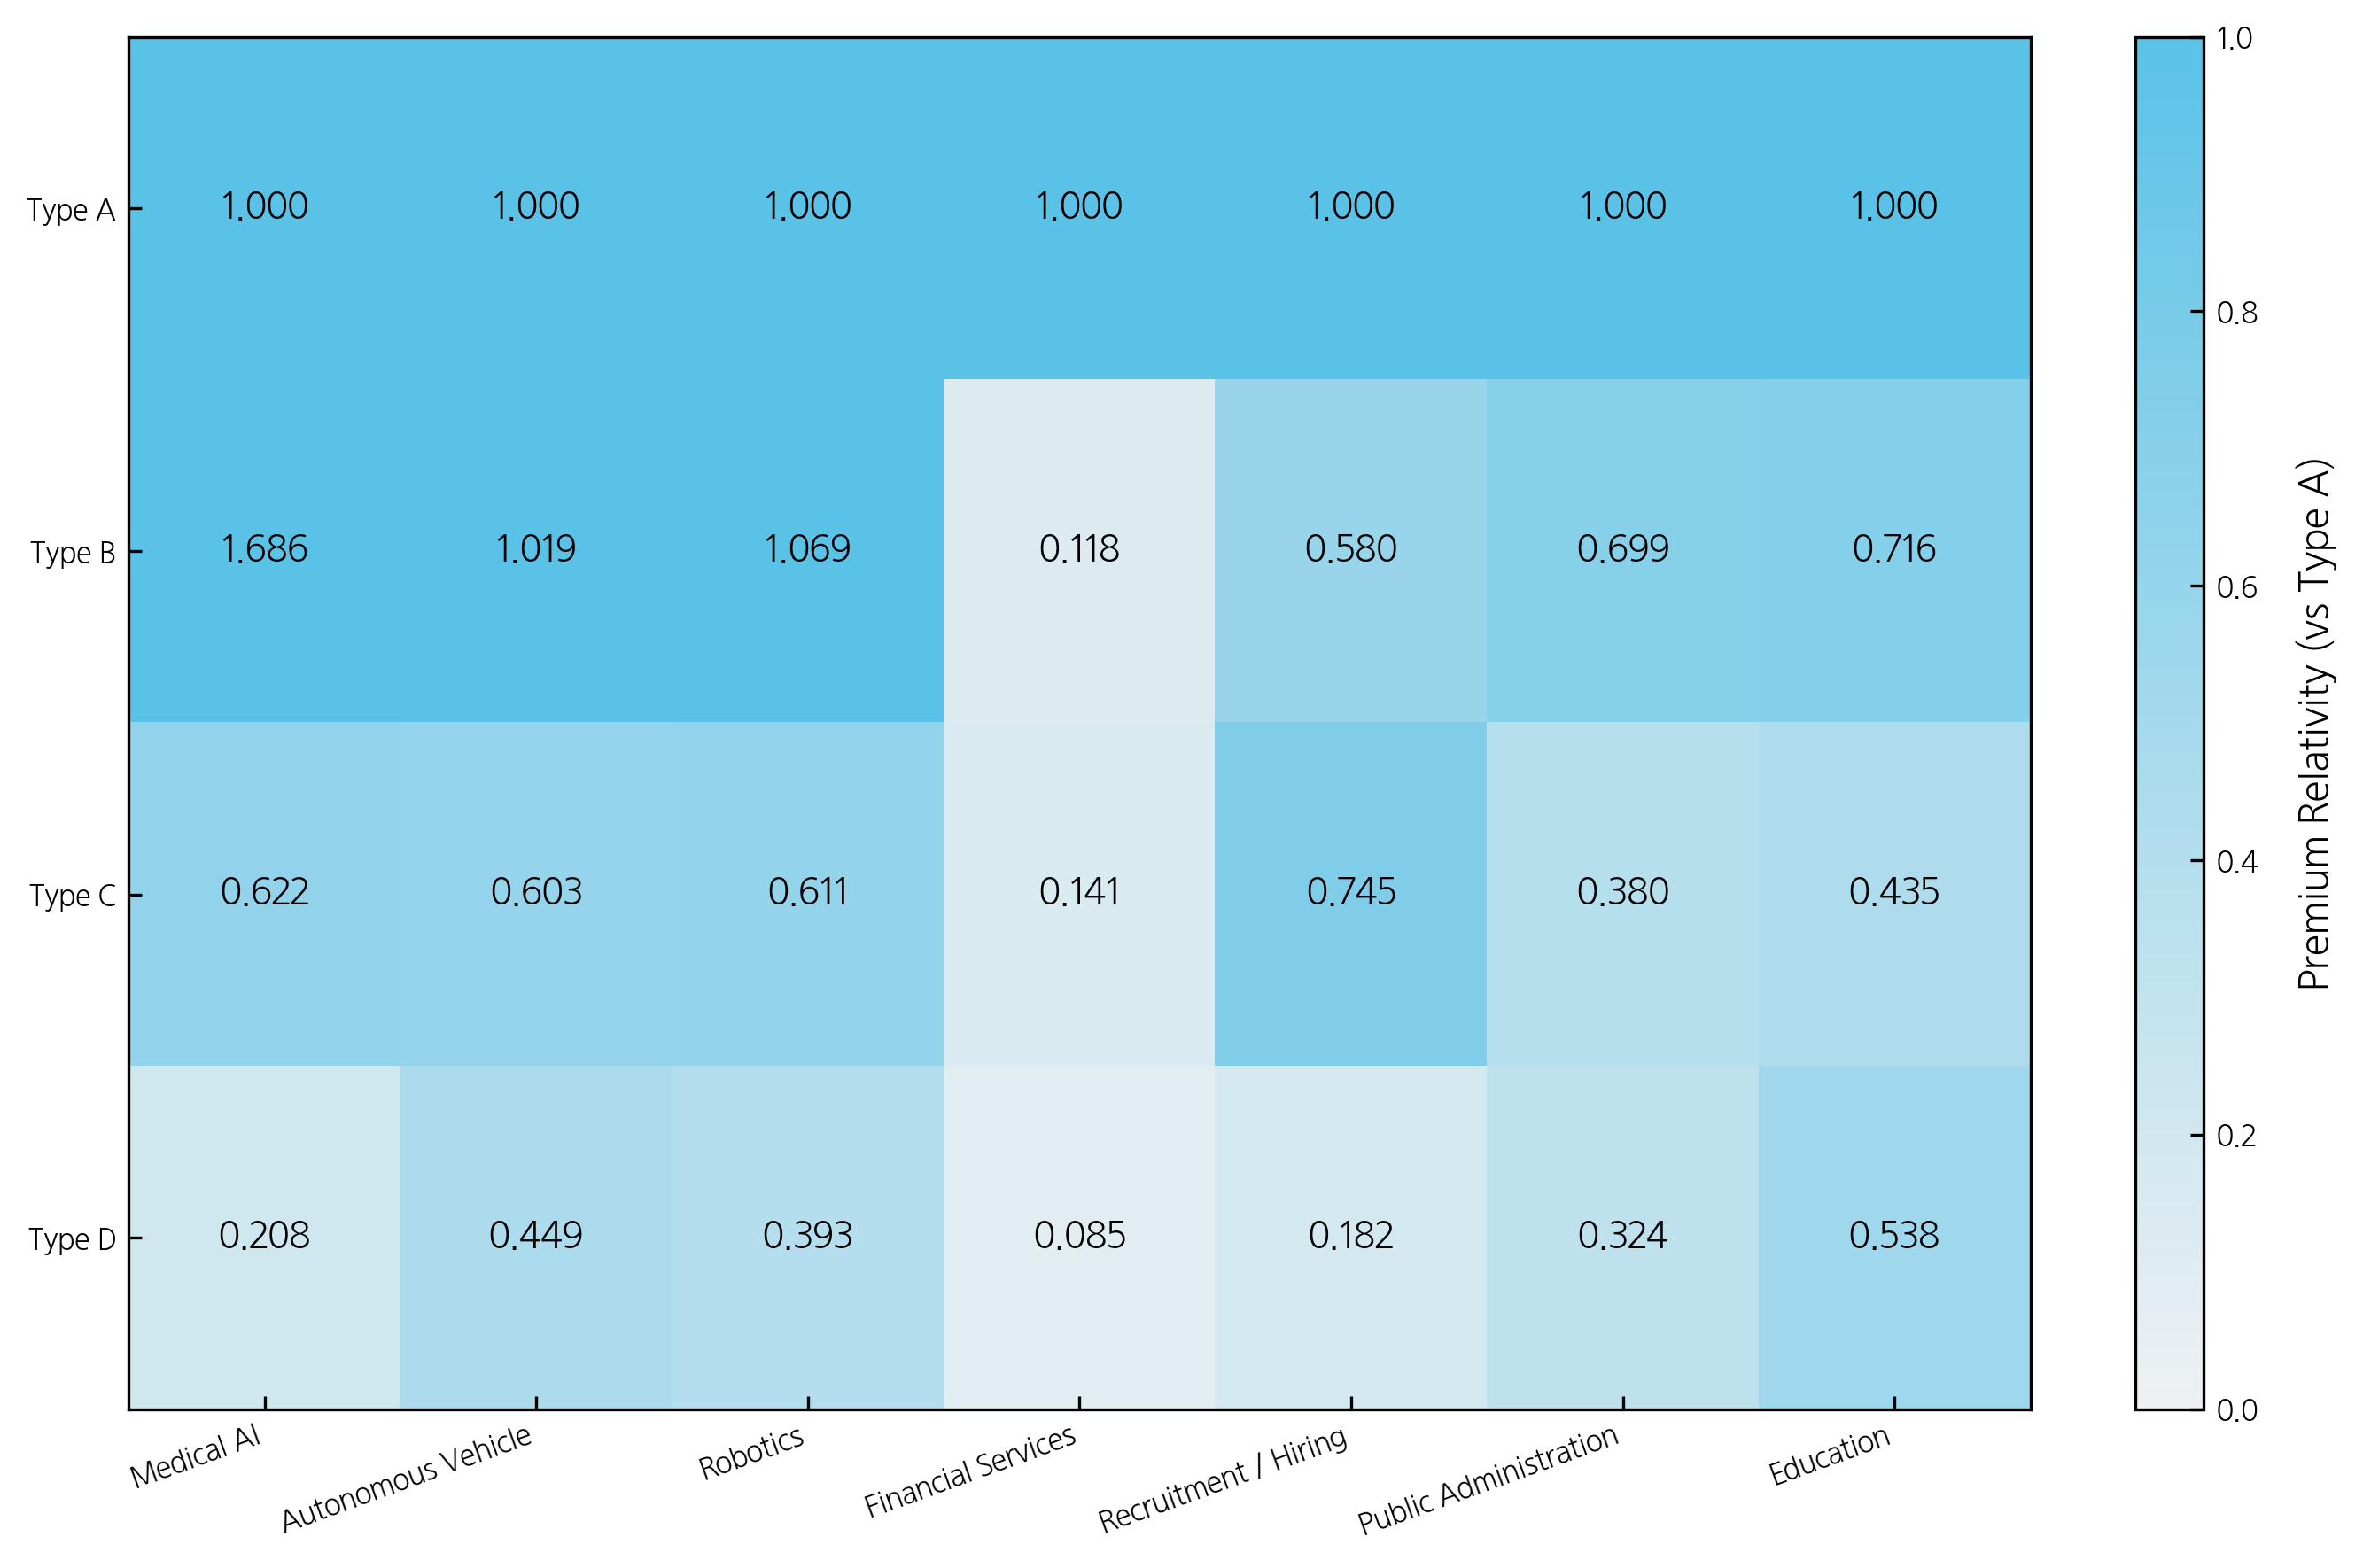

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


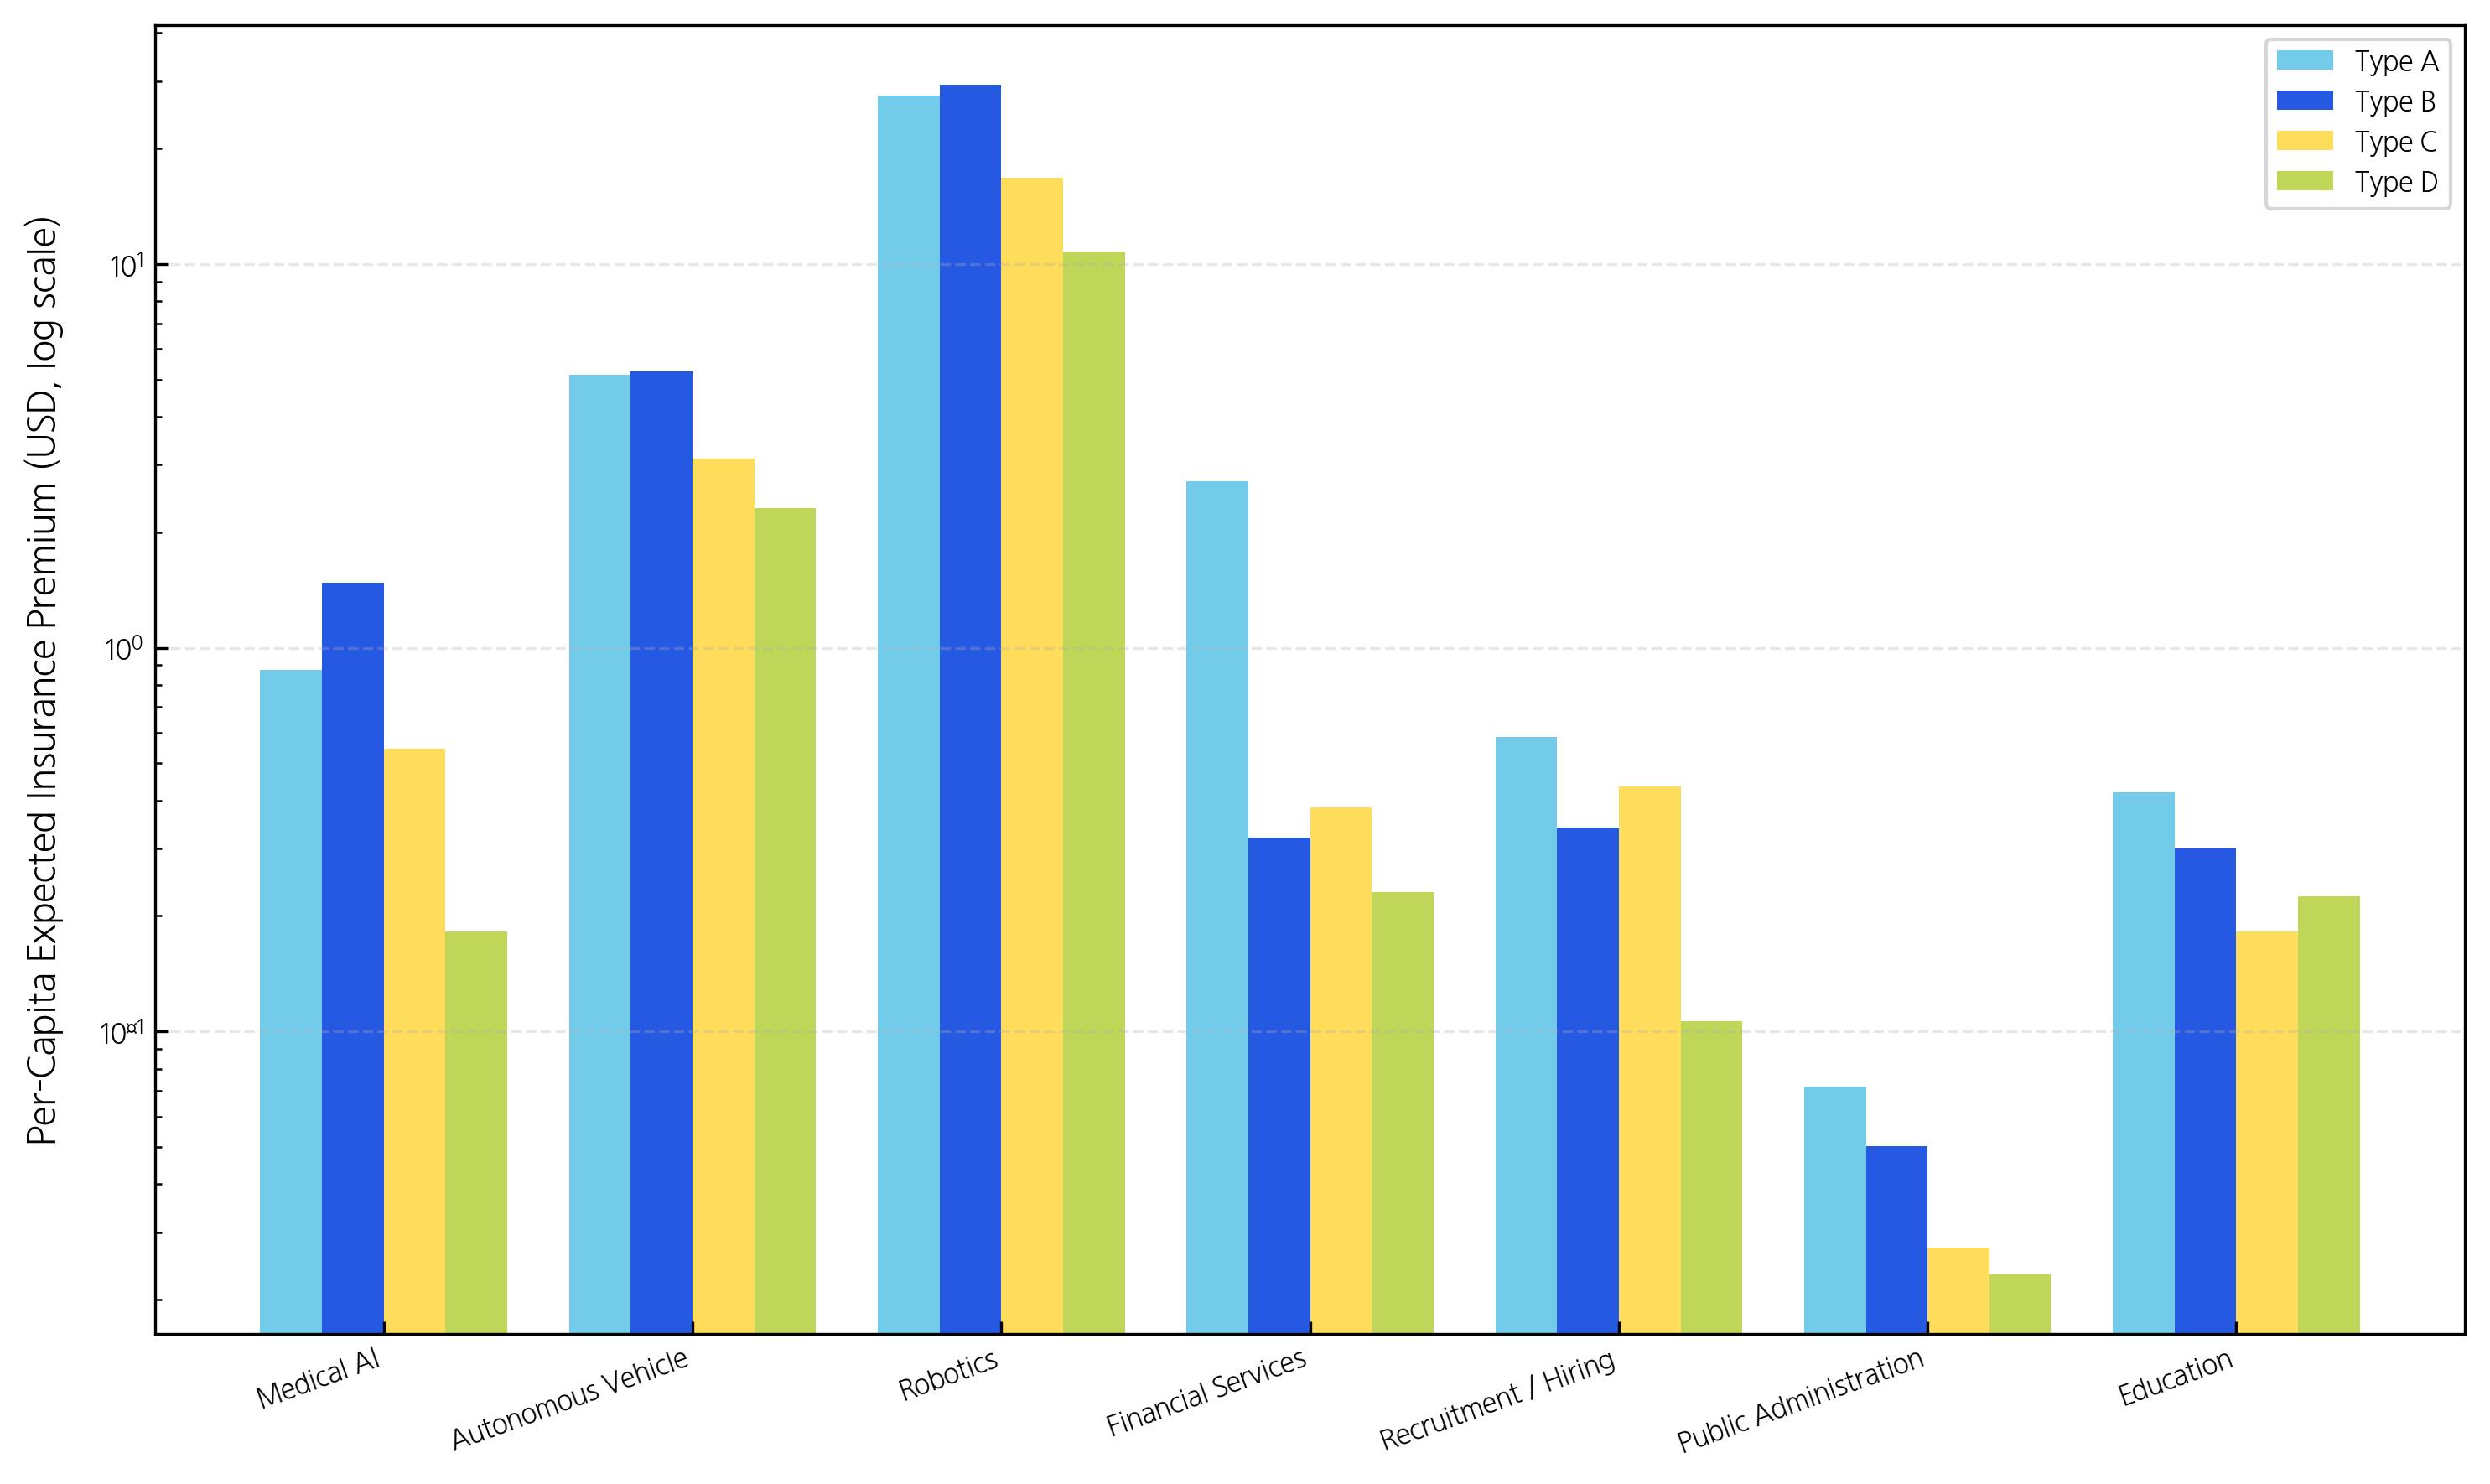

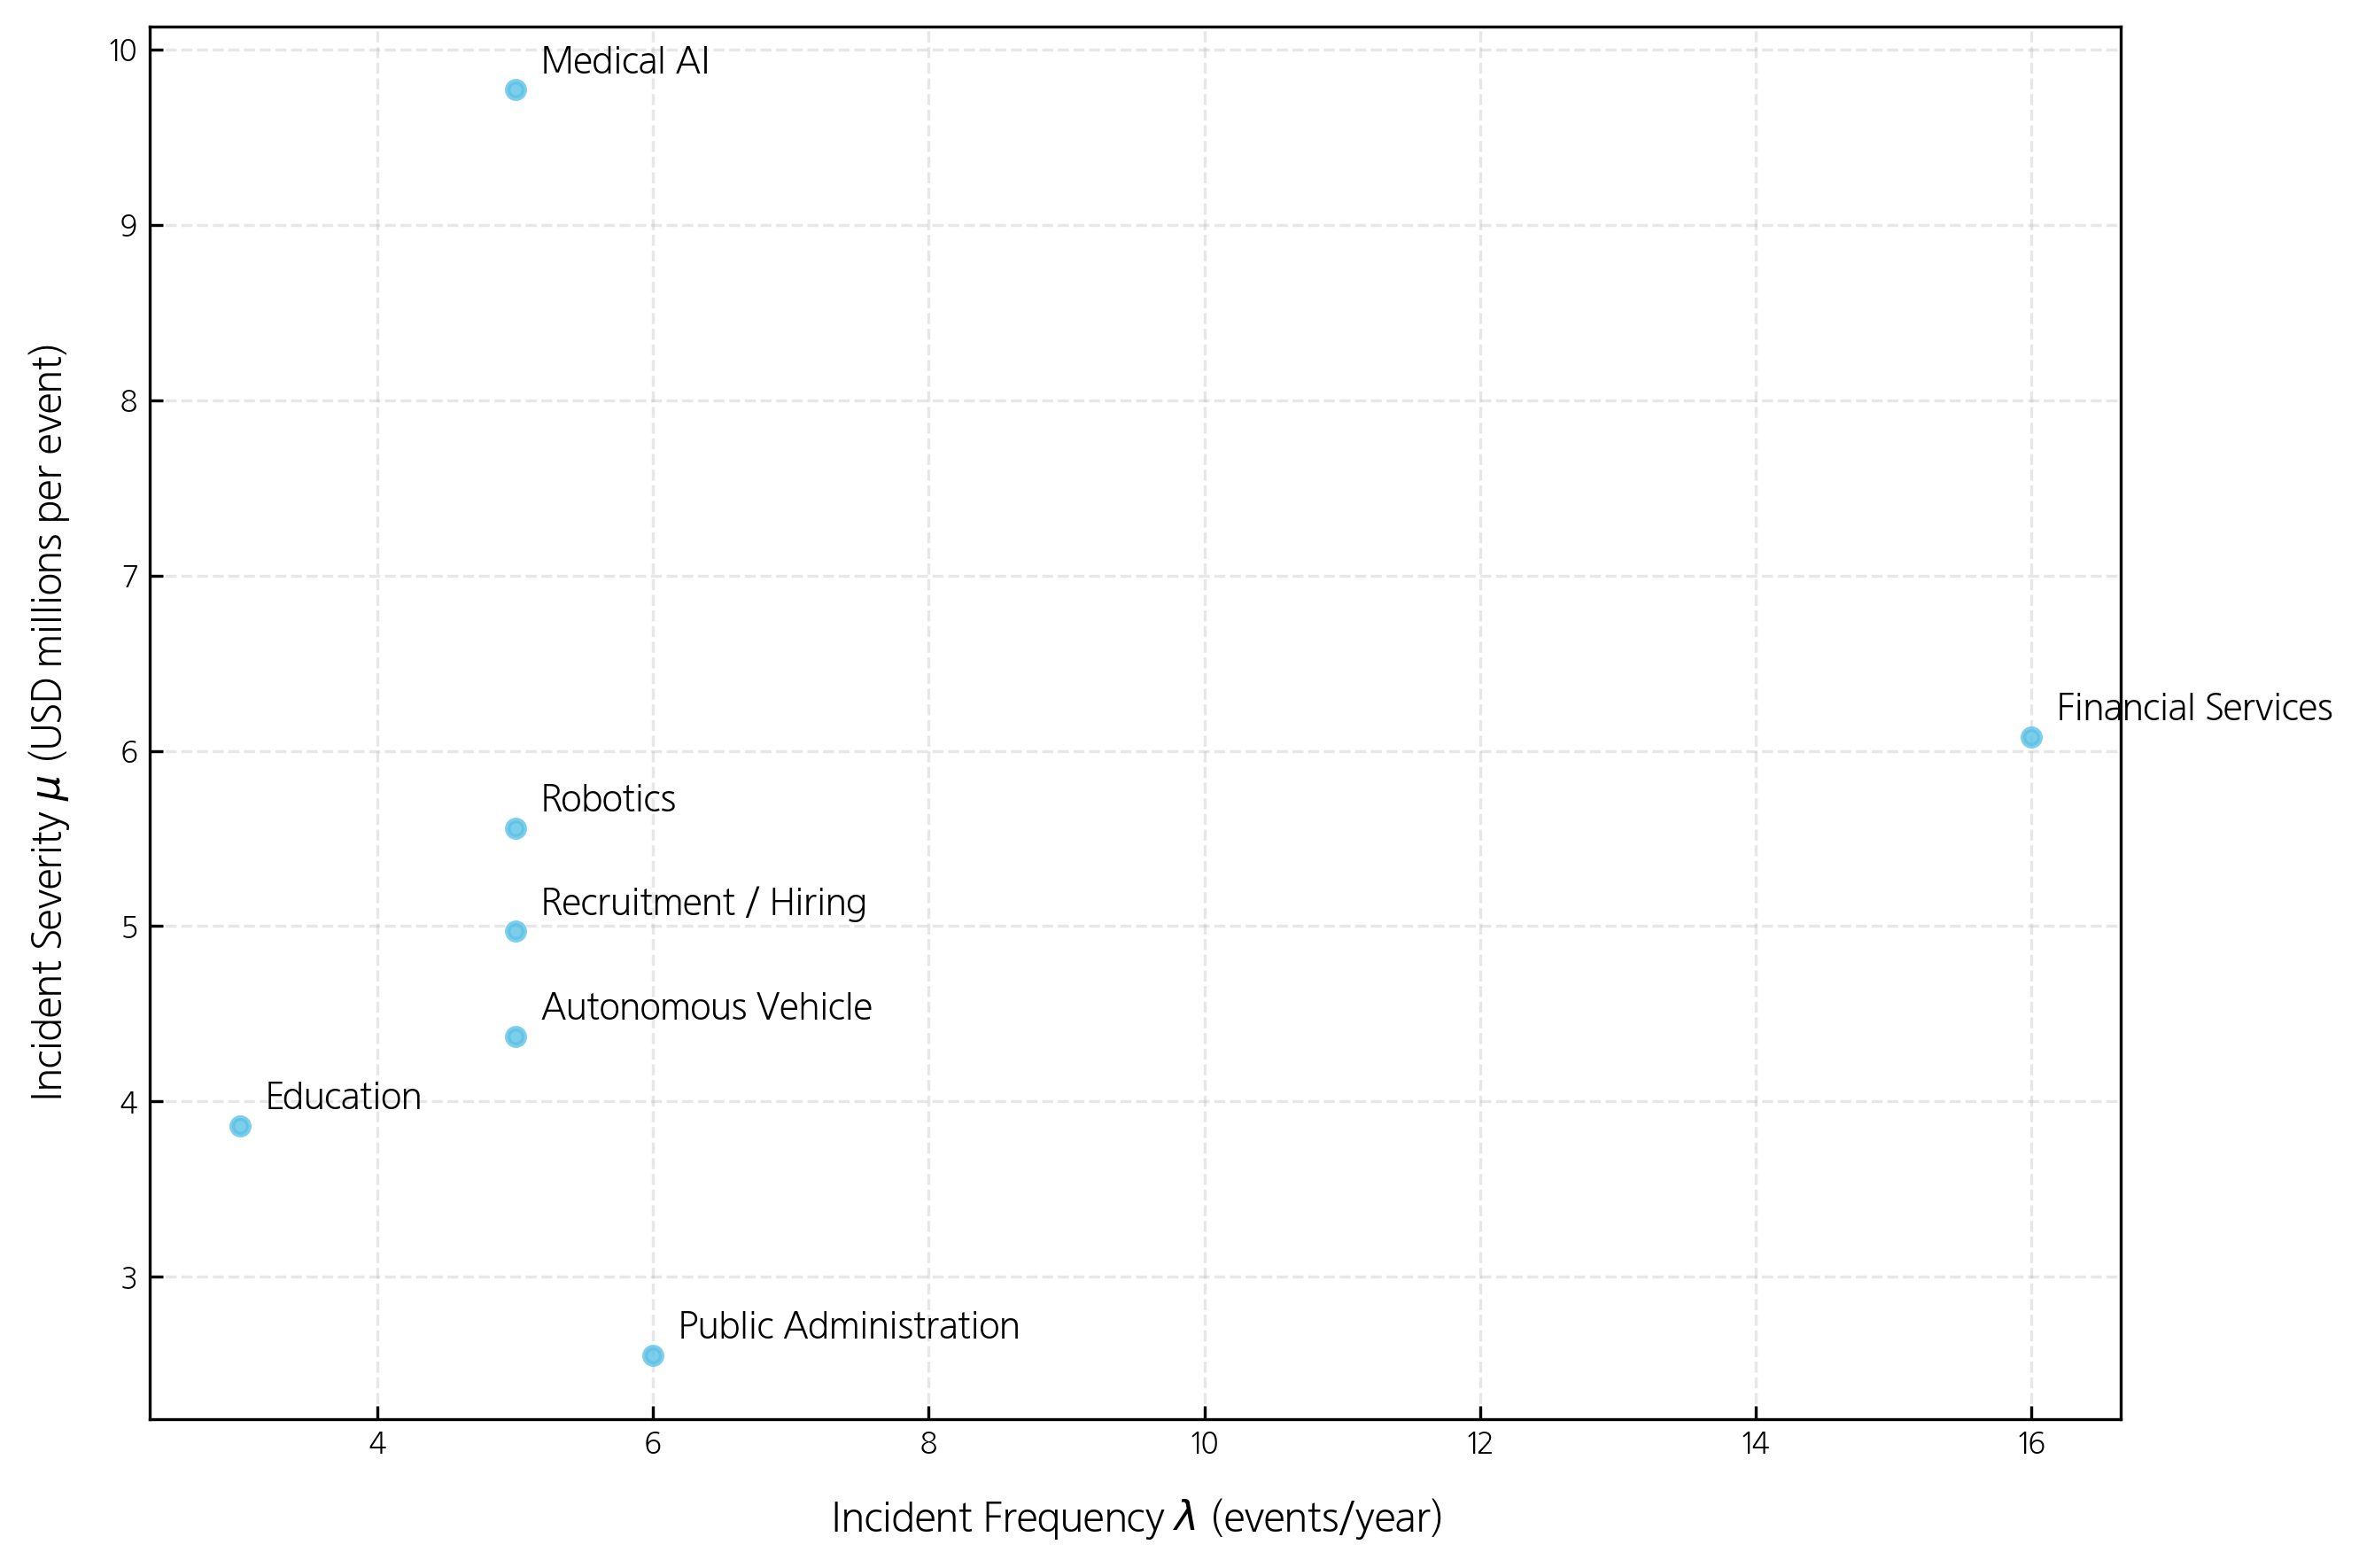

In [4]:
# ─────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────

# Plot 1 — Heatmap of Premium Relativity
custom_cmap = sns.light_palette(
    "#5BC2E7",
    as_cmap=True
)
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)
im = ax.imshow(piv_rel.values, cmap=custom_cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(domain_order)))
ax.set_yticks(np.arange(len(type_order)))

ax.set_xticklabels(
    [f"{d}" for d in domain_order],
    rotation=20, ha='right'
)
ax.set_yticklabels(type_order)

#ax.set_xlabel('AI Application Domain')
#ax.set_ylabel('Governance Maturity Scenario')

ax.grid(False)
#ax.set_title('Heatmap of Premium Relativity', fontweight='bold')

for i in range(len(type_order)):
    for j in range(len(domain_order)):
        v = piv_rel.values[i, j]
        ax.text(
            j, i, f'{v:.3f}',
            ha='center', va='center',
            #color='black' if v > 0.3 else 'white'
            color='black'
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.04)
cbar.set_label('Premium Relativity (vs Type A)')
plt.tight_layout()
plt.savefig("figures/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# Plot 2 — Per-Capita Annual Premium (USD, log scale)
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

x_pos = np.arange(len(domain_order))
width = 0.20

for i, typ in enumerate(type_order):
    vals = piv_pc.loc[typ].values
    ax.bar(
        x_pos + i*width,
        vals,
        width,
        label=typ,
        color=colors[i],
        alpha=0.85
    )

ax.set_yscale('log')

ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(domain_order, rotation=20, ha='right')

#ax.set_title('Per-Capita Annual Premium by Governance Type\n(USD / person / year, log scale)',
#            fontweight='bold')
ax.set_ylabel('Per-Capita Expected Insurance Premium (USD, log scale)')

ax.legend()
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("figures/premium.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Plot 3: Industry Risk Profile (μ × λ scatter) ---
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

mus = [DOMAINS[d]['mu_USD']/1e6 for d in domain_order]
lams = [DOMAINS[d]['lambda_global'] for d in domain_order]
'''grades = [DOMAINS[d]['grade'] for d in domain_order]

grade_color = {
    'A':'#2ecc71',
    'B':'#f39c12',
    'C':'#e74c3c'
}'''

for i, d in enumerate(domain_order):
    ax.scatter(
        lams[i],
        mus[i],
        s=20,
        color=colors[0],
        edgecolors=colors[0],
        linewidth=1.5,
        alpha=0.8,
        zorder=3
    )

    ax.annotate(
        d,
        (lams[i], mus[i]),
        xytext=(7, 5),
        textcoords='offset points'
    )

ax.set_xlabel(r'Incident Frequency $\lambda$ (events/year)')
ax.set_ylabel(r'Incident Severity $\mu$ (USD millions per event)')

#ax.set_title(r'Industry Risk Profile: Frequency ($\lambda$) vs. Severity ($\mu$)', fontweight='bold')

ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("figures/riskportfolio.png", dpi=300, bbox_inches="tight")
plt.show()

## Section 4 — Visualisation

Four charts are produced:

1. **Premium Relativity Heatmap** — governance type × domain  
2. **Per-Capita Annual Premium** — bar chart (log scale)  
3. **Industry Risk Profile** — scatter of $\lambda$ vs $\mu$  


Computing individual premiums for 125 actual AIID incidents...

[ Premium Estimation Summary — Actual AIID Incidents ]
                      calc_G_ops Individual_Premium_USD                \
                            mean                   mean           min   
domain                                                                  
Autonomous Vehicle          0.79           3.973483e+10  3.433879e+10   
Education                   0.81           2.694716e+10  2.349290e+10   
Financial Services          0.85           9.502926e+10  8.548437e+10   
Medical AI                  0.86           8.523990e+10  7.677116e+10   
Public Administration       0.85           2.436905e+10  2.195063e+10   
Recruitment / Hiring        0.78           4.570613e+10  3.905350e+10   
Robotics                    0.77           5.114896e+10  4.368963e+10   

                                    Per_Capita_KRW  
                                max           mean  
domain                                      

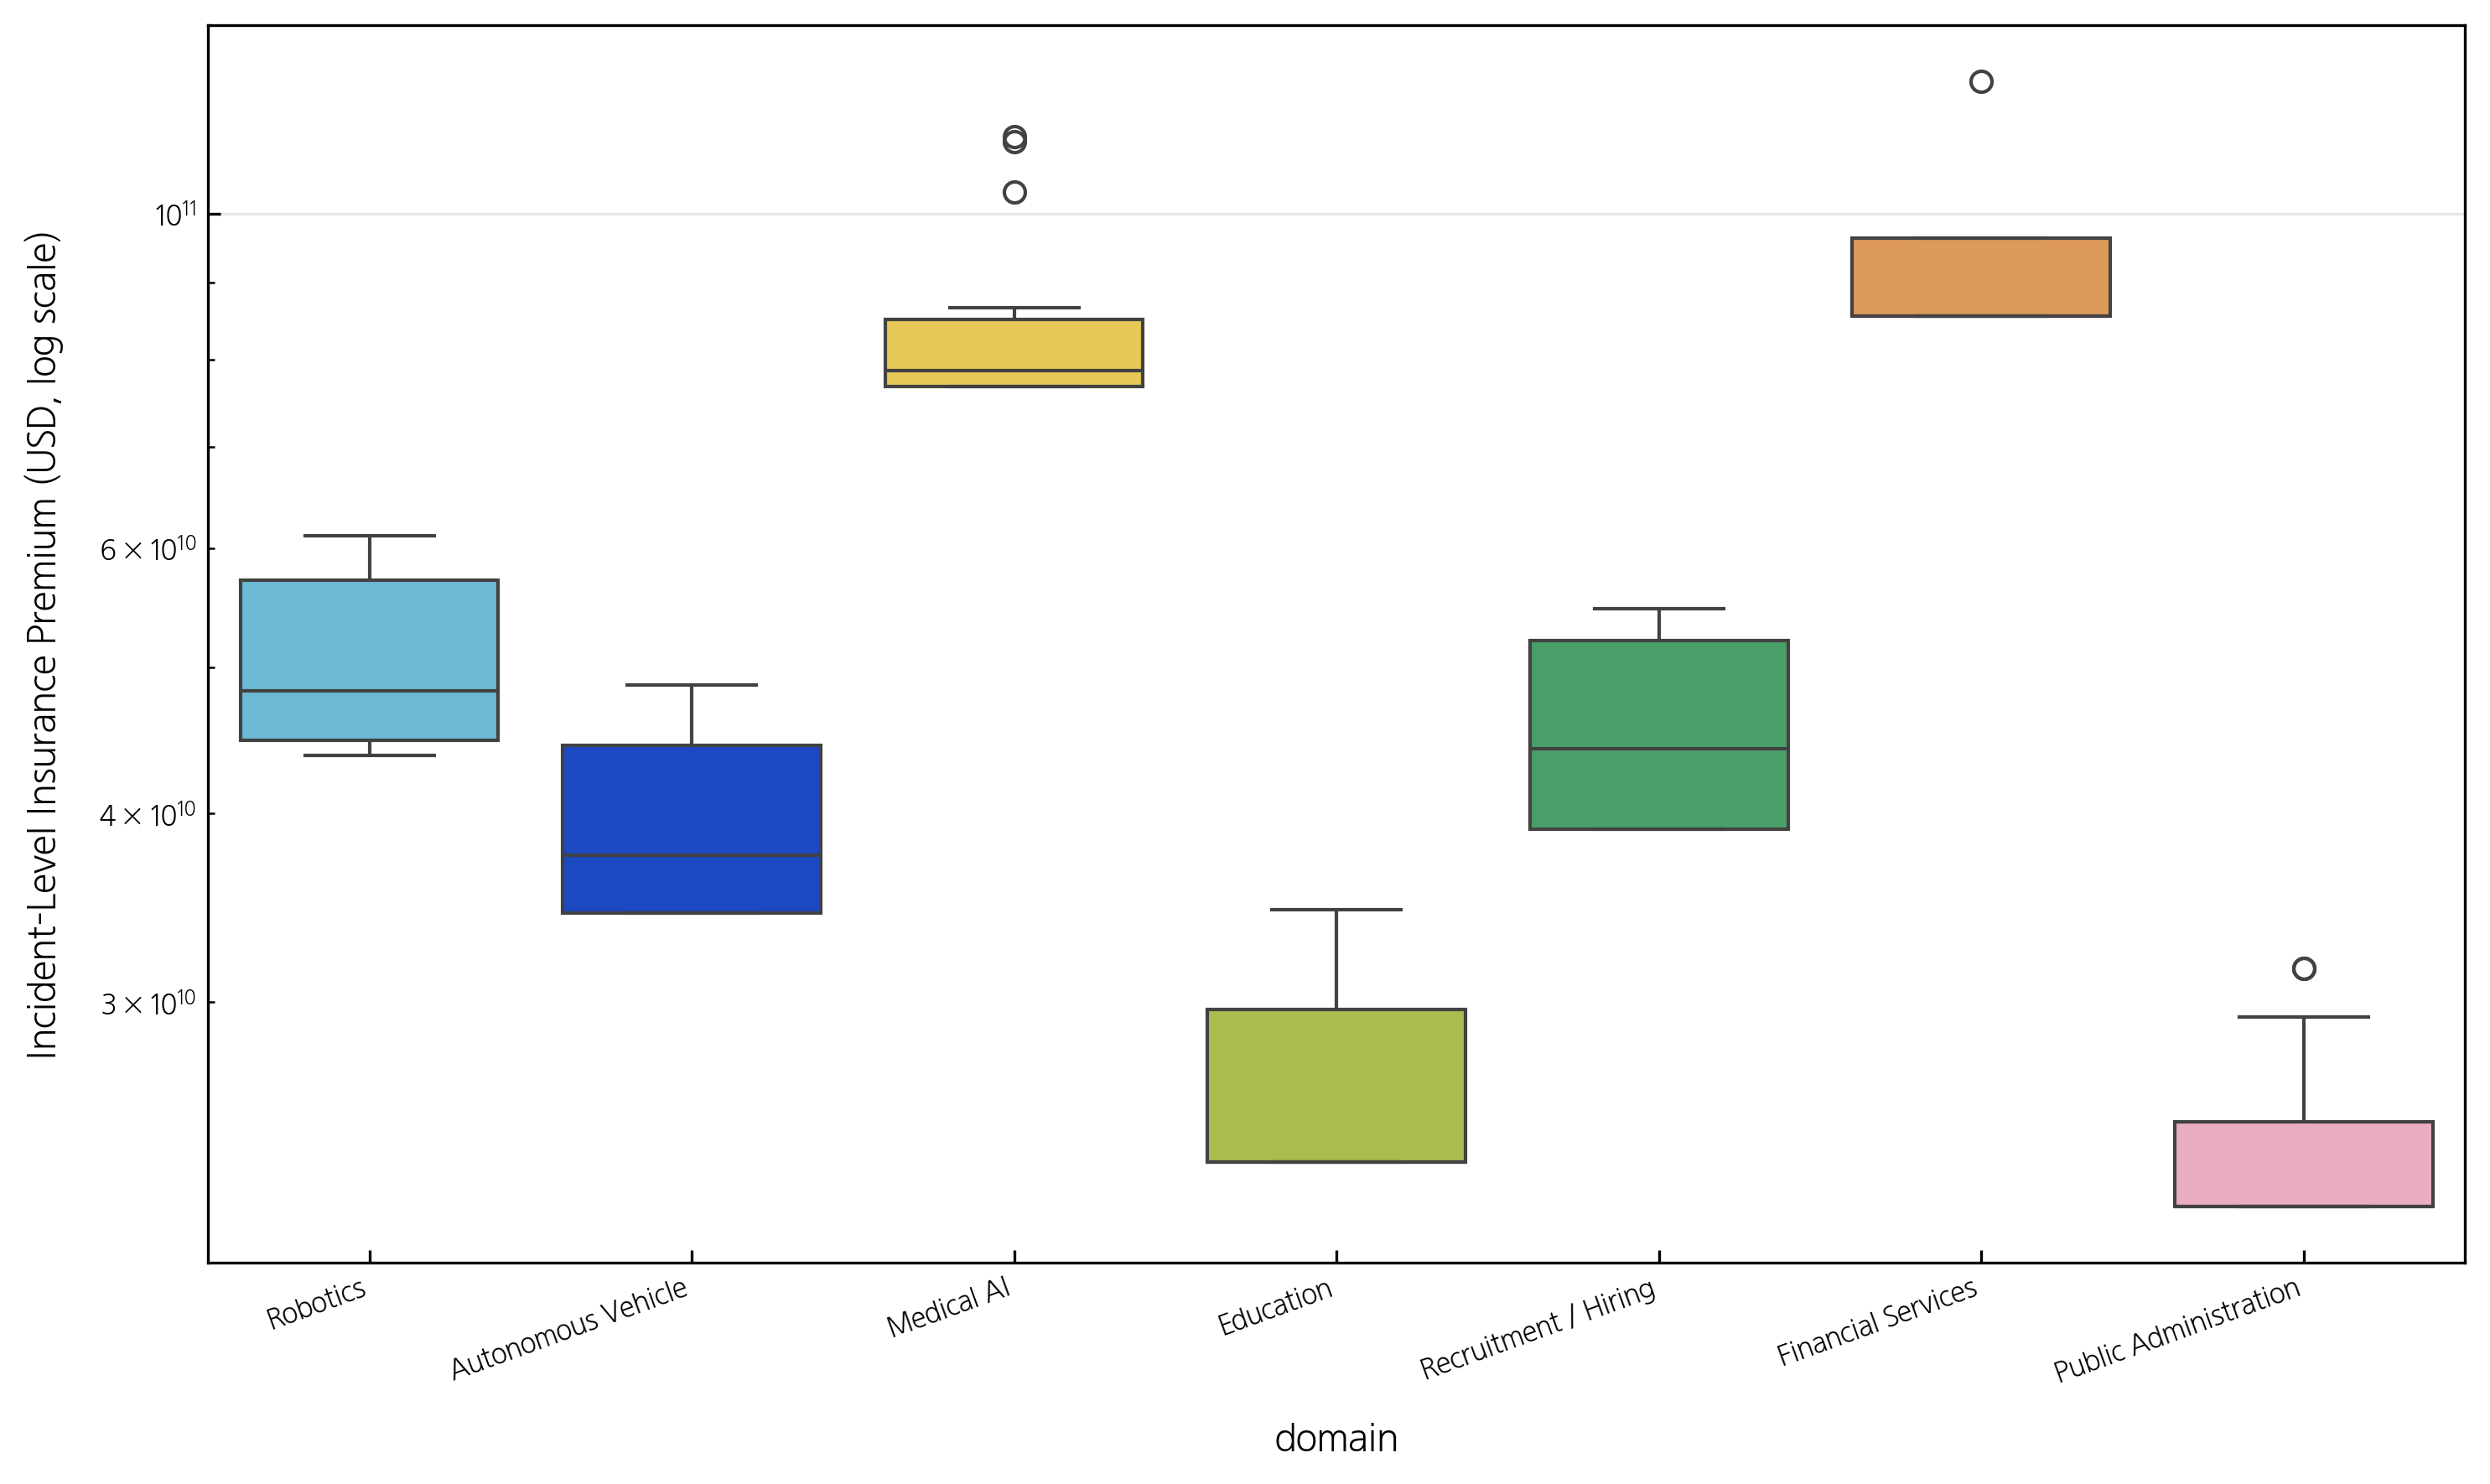

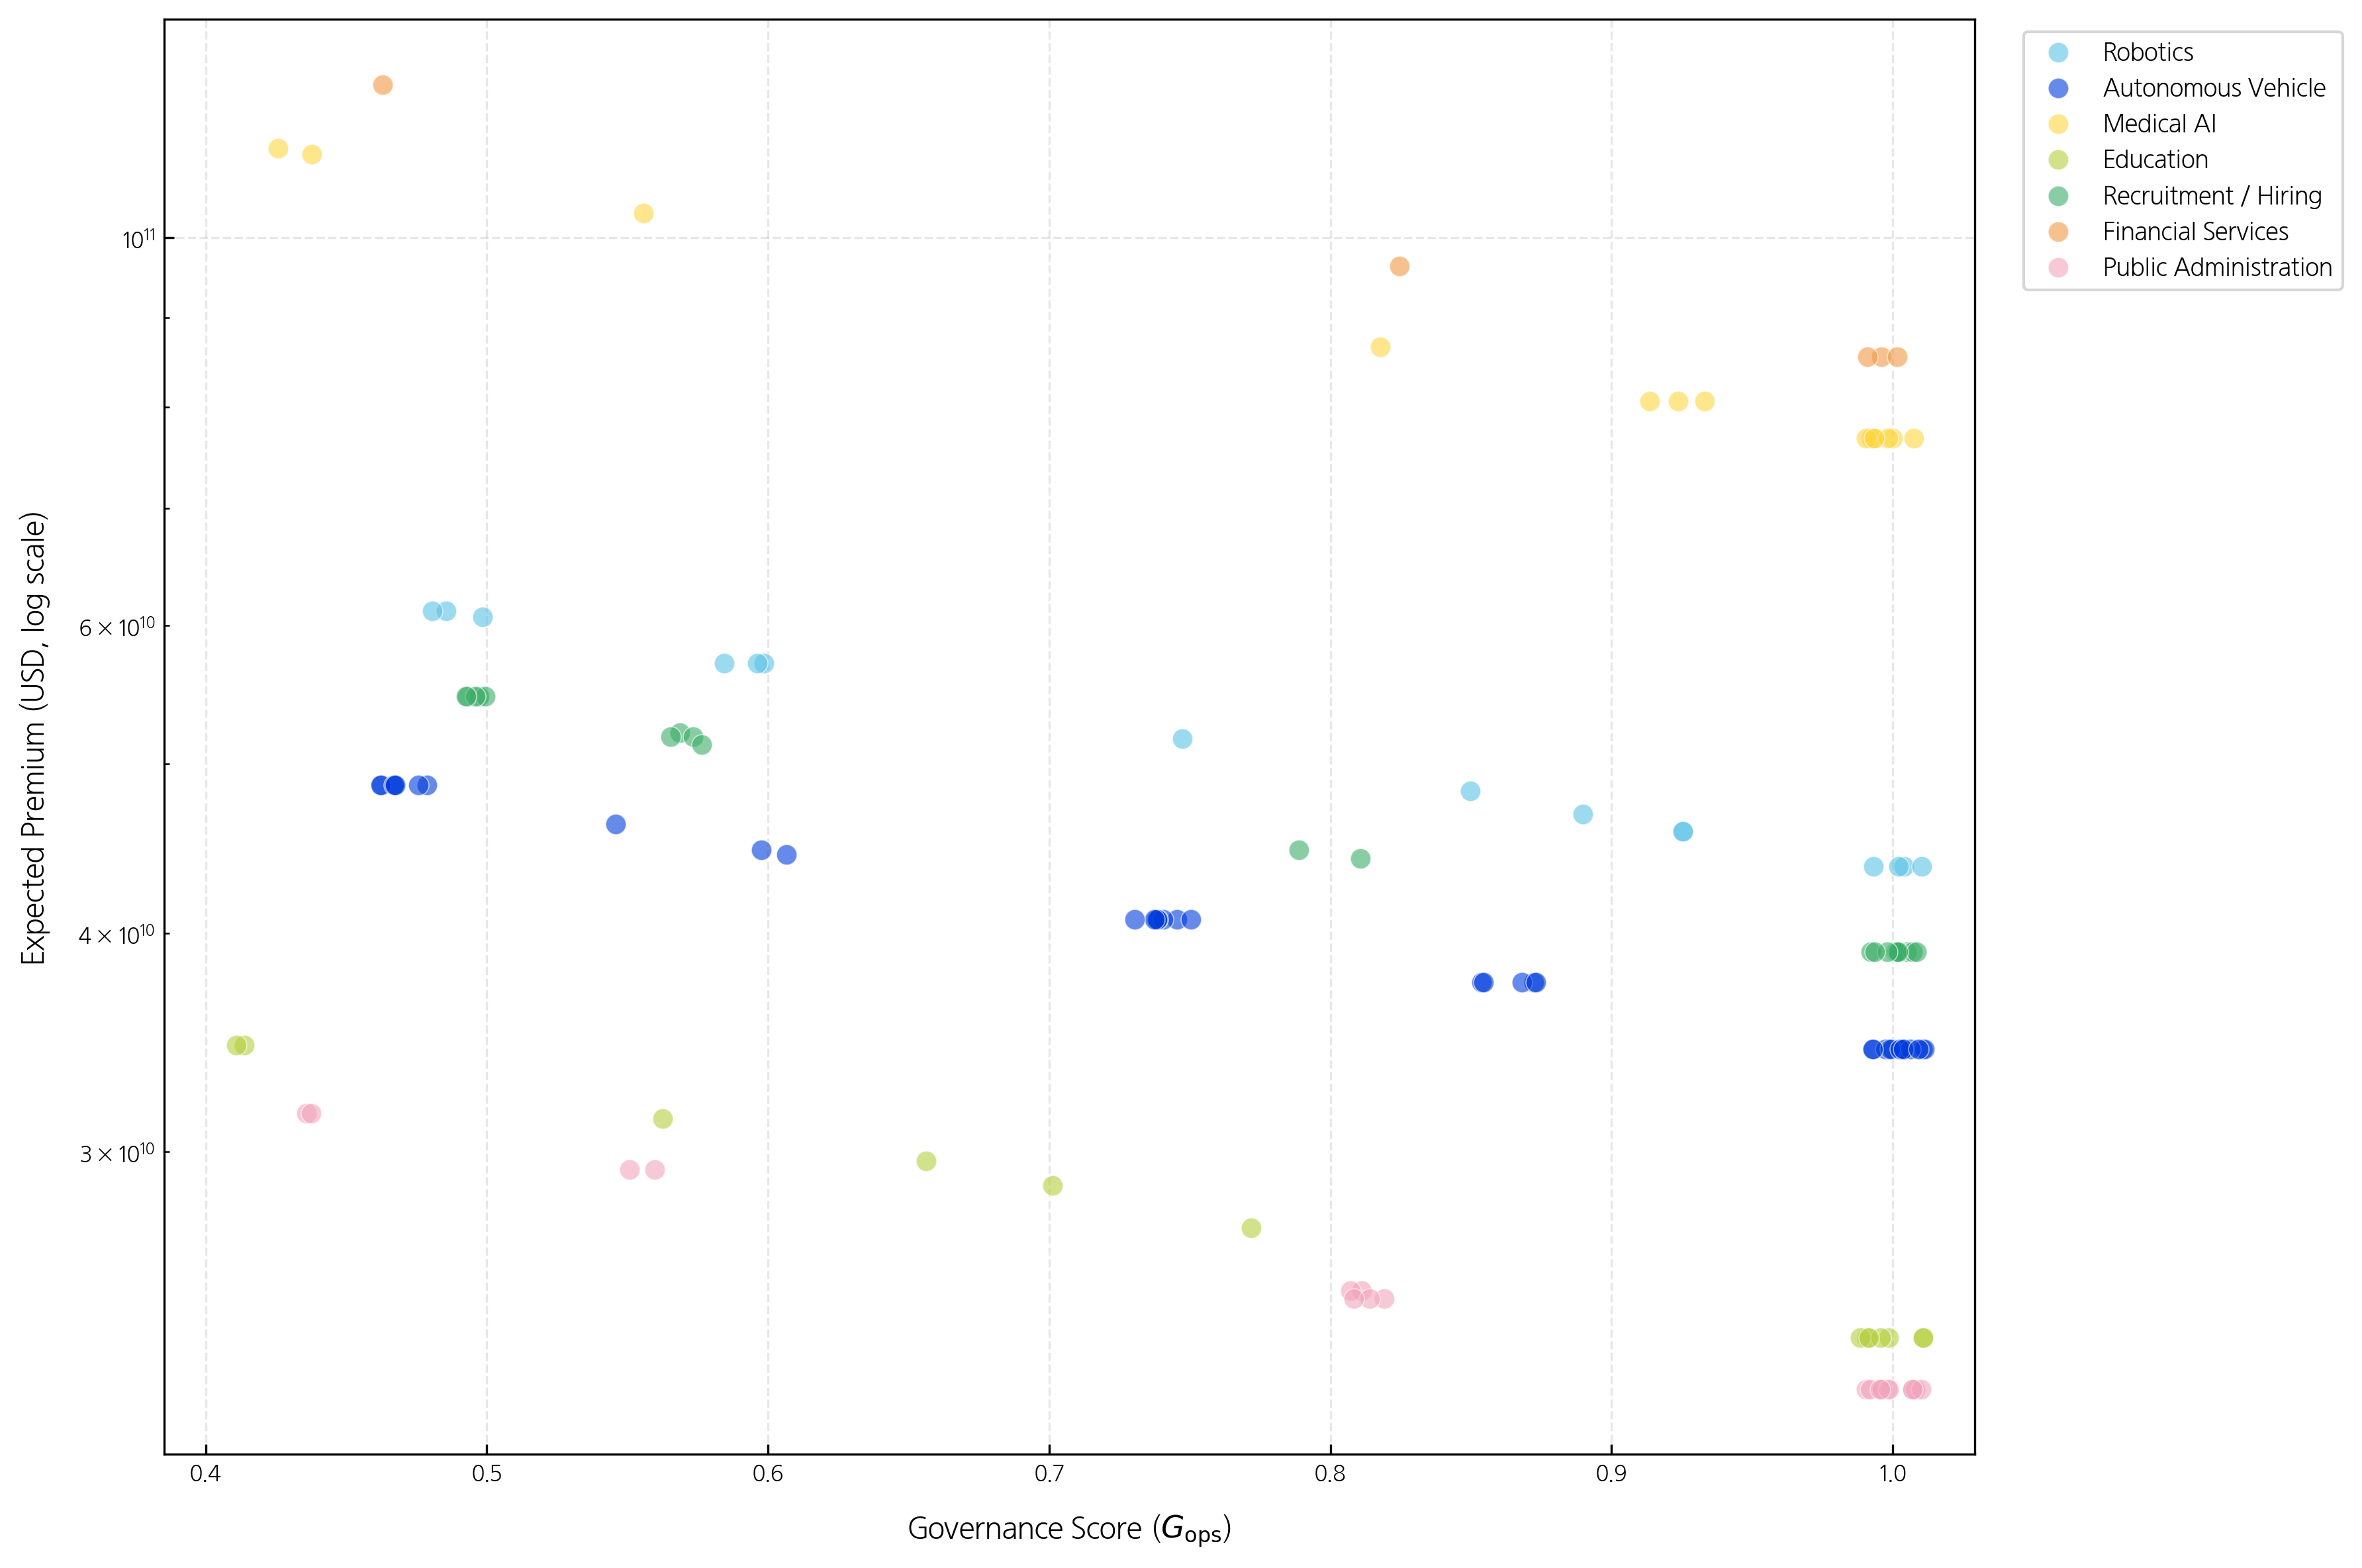

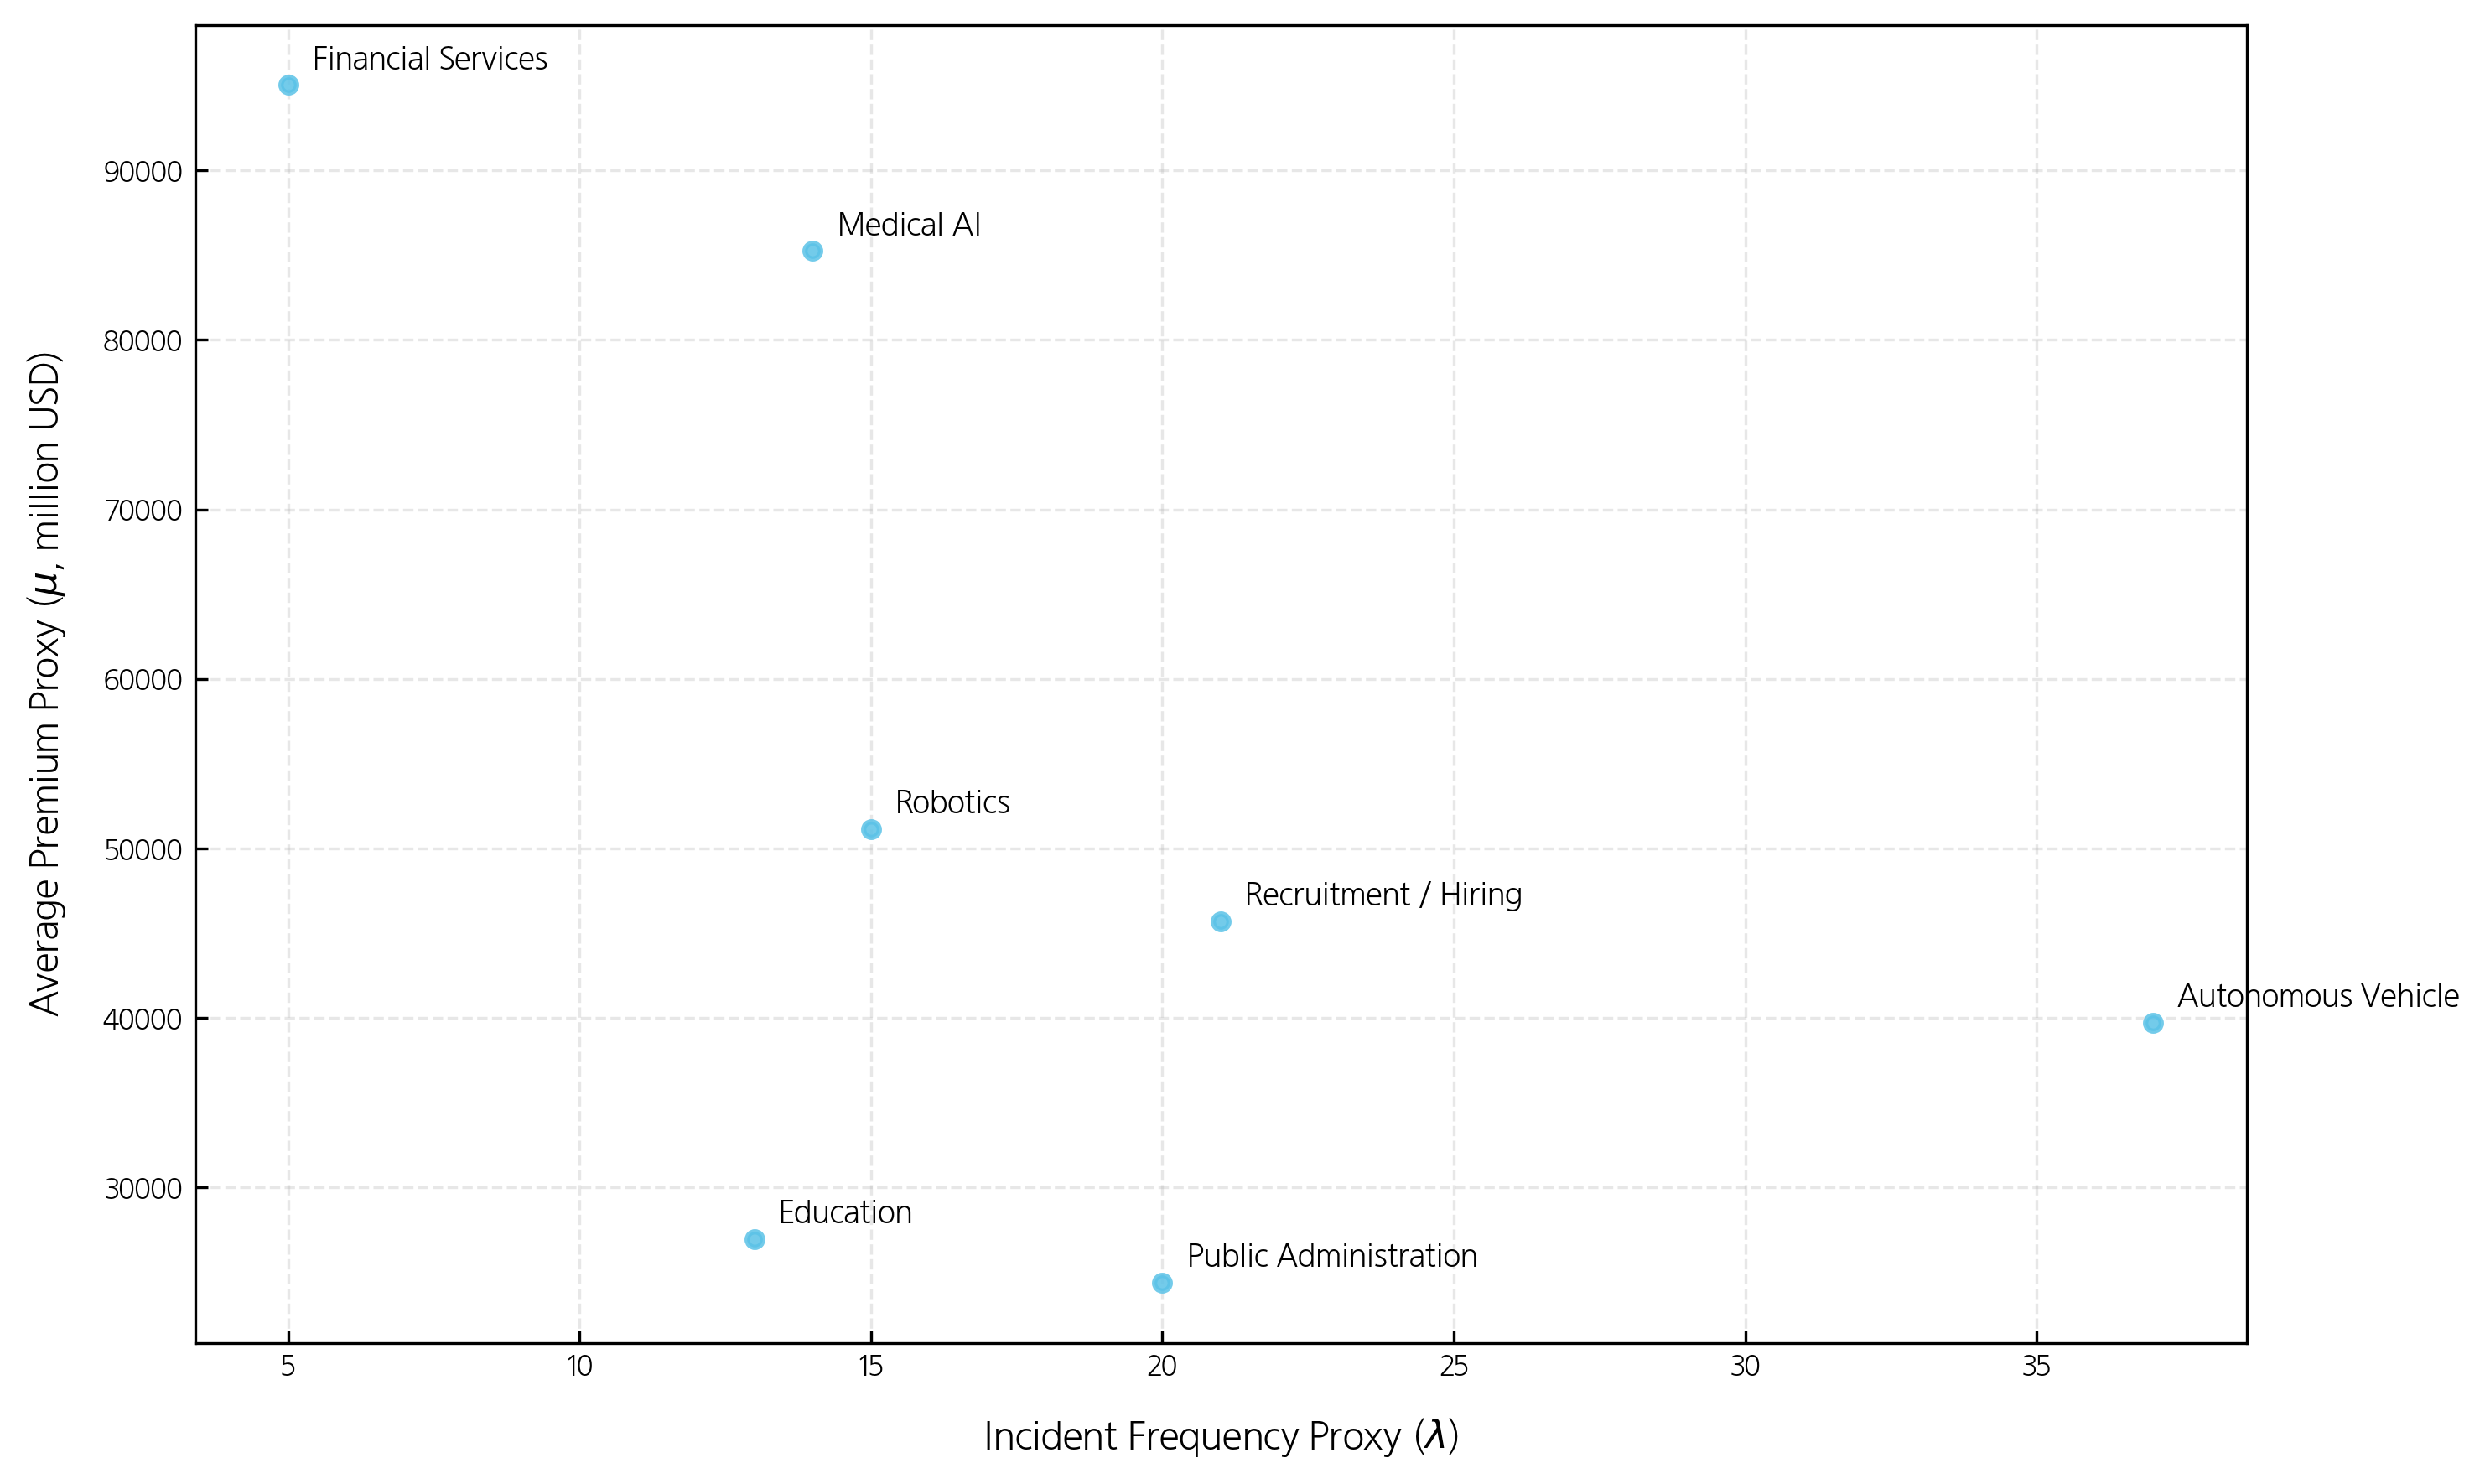

In [5]:
# ─────────────────────────────────────────────
# 1. Load and Preprocess Actual Incident Data
# ─────────────────────────────────────────────
try:
    # Load data (verify file path)
    real_df = pd.read_csv("aiid_incident_scores.csv")
    
    # Map domain names in CSV to DOMAINS dictionary keys
    # Adjust to match actual 'domain' column values in the CSV
    domain_map = {
        'Medical AI': 'Medical AI', 
        'Autonomous Vehicle': 'Autonomous Vehicle', 
        'Robotics': 'Robotics',
        'Financial Services': 'Financial Services', 
        'Recruitment / Hiring': 'Recruitment / Hiring', 
        'Public Administration': 'Public Administration', 
        'Education': 'Education',
    }
    real_df['domain_eng'] = real_df['domain'].map(domain_map)
    
    # Drop rows where domain mapping is unavailable
    real_df = real_df.dropna(subset=['domain_eng'])
    
except FileNotFoundError:
    print("Error: aiid_incident_scores.csv not found.")
    real_df = pd.DataFrame()

# ─────────────────────────────────────────────
# 2. Individual Premium Estimation Function
# ─────────────────────────────────────────────
def calculate_individual_premium(row):
    dom_name = row['domain_eng']
    if dom_name not in DOMAINS:
        return pd.Series([np.nan]*4)
    
    # A. Retrieve domain parameters and governance weights
    params = DOMAINS[dom_name]
    weights = DOMAIN_WEIGHTS.get(dom_name, W)
    
    # B. Recompute G_ops from actual control scores (domain-weighted)
    # Assumes columns D, Q, T, H, M, R, C, S exist in the CSV
    g_score = sum(weights[c] * row.get(c, 0) for c in weights)
    
    # C. Determine effective risk parameters
    # Frequency reduction: λ_eff = λ_global × exp(-γ × G_ops)
    lam_eff = params['lambda_global'] * np.exp(-GAMMA * g_score)
    
    mu_eff = params['mu_USD']  # severity loading disabled (matches main simulation)
    
    # D. Closed-form expected loss (faster than Monte Carlo for per-row calc.)
    # Use analytical formulas for speed (row-by-row computation)
    # E[L] = λ·μ;  Var[L] = λ·μ²·exp(σ²)  [compound Poisson property]
    el_val = lam_eff * mu_eff
    
    # Risk loading via std-dev proxy for TVaR (actuarial approximation)
    # This value is reported as the pure premium in the analysis
    safety_margin = 1.96 * np.sqrt(lam_eff * (mu_eff**2 * (np.exp(SIGMA**2) - 1))) # 95% confidence interval approximation
    
    raw_premium = (el_val + PHI * safety_margin) * (1 + THETA) / (1 - EXP_RATIO)
    per_capita_krw = (raw_premium / params['D_pop']) * 1380
    
    return pd.Series([g_score, raw_premium, per_capita_krw])

# ─────────────────────────────────────────────
# 3. Execute Calculation and Merge Results
# ─────────────────────────────────────────────
if not real_df.empty:
    print(f"Computing individual premiums for {len(real_df)} actual AIID incidents...")
    
    # Apply premium function row-wise
    real_df[['calc_G_ops', 'Individual_Premium_USD', 'Per_Capita_KRW']] = \
        real_df.apply(calculate_individual_premium, axis=1)

    # ─────────────────────────────────────────────
    # 4. Results Summary and Statistics
    # ─────────────────────────────────────────────
    summary = real_df.groupby('domain').agg({
        'calc_G_ops': 'mean',
        'Individual_Premium_USD': ['mean', 'min', 'max'],
        'Per_Capita_KRW': 'mean'
    }).round(2)

    print("\n" + "="*80)
    print("[ Premium Estimation Summary — Actual AIID Incidents ]")
    print("="*80)
    print(summary)

# ─────────────────────────────────────────────
# 4. Results Summary and Visualisation
# ─────────────────────────────────────────────

if not real_df.empty:
    real_summary = real_df.groupby('domain_eng').agg({
    'calc_G_ops': 'mean',
    'Individual_Premium_USD': 'mean',
    'Per_Capita_KRW': 'mean'}).reset_index()
    
    # =========================================================
    # Plot 1. Actual Incident Premium Distribution (Boxplot)
    # =========================================================
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    sns.boxplot(
        x='domain',
        y='Individual_Premium_USD',
        data=real_df,
        ax=ax,
        palette=colors
    )

    ax.set_yscale('log')

    '''ax.set_title(
        'Actual Incident Premium Distribution by Domain',
        fontweight='bold',
        pad=15
    )'''

    #ax.set_xlabel('AI Application Domain')
    ax.set_ylabel('Incident-Level Insurance Premium (USD, log scale)')

    ax.grid(True, alpha=0.3, axis='y')

    plt.xticks(rotation=20, ha='right')

    plt.tight_layout()
    plt.show()


    # =========================================================
    # Plot 2. Governance Score vs Premium Decay
    # =========================================================
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

    # Domain colours — Samsung Fire & Marine palette (same as simulation plots)
    palette_colors = [
        '#5BC2E7', '#003CDC', '#FED63F', '#B4CF3C',
        '#3AAD67', '#F39945', '#F2A4BC', '#F96D69'
    ]
    domains_in_data = list(real_df['domain_eng'].dropna().unique())
    dom_colors = {
        dom: palette_colors[i % len(palette_colors)]
        for i, dom in enumerate(domains_in_data)
    }

    # Determine x-axis range from actual data (no fixed 0–1 span)
    x_all = real_df['calc_G_ops'].dropna()
    x_pad = (x_all.max() - x_all.min()) * 0.05
    x_min_data = x_all.min() - x_pad
    x_max_data = x_all.max() + x_pad

    for dom in domains_in_data:

        dom_data = real_df[real_df['domain_eng'] == dom].copy()
        dom_data = dom_data.sort_values('calc_G_ops')
        if dom_data.empty:
            continue

        # Add small jitter on x-axis so overlapping points become visible
        jitter_scale = (x_all.max() - x_all.min()) * 0.02
        dom_data['x_jitter'] = (
            dom_data['calc_G_ops']
            + np.random.uniform(-jitter_scale, jitter_scale, len(dom_data))
        )

        # Individual incident scatter
        ax.scatter(
            dom_data['x_jitter'],
            dom_data['Individual_Premium_USD'],
            color=dom_colors[dom],
            alpha=0.60,
            s=55,
            edgecolors='white',
            linewidth=0.4,
            label=dom,
            zorder=3
        )

    # Axis — restrict to actual data range
    ax.set_yscale('log')
    ax.set_xlim(x_min_data, x_max_data)

    '''ax.set_title(
        'Governance Efficacy and Premium Risk Decay\n'
        'Each point = one AIID incident; jitter applied for visibility',
        fontweight='bold',
        pad=15
    )'''
    ax.set_xlabel(r'Governance Score ($G_{\mathrm{ops}}$)')
    ax.set_ylabel(r'Expected Premium (USD, log scale)')
    ax.grid(True, linestyle='--', alpha=0.3)

    # Legend
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=9,
        frameon=True
    )

    plt.tight_layout()
    plt.savefig('figures/governance_premium_decay.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================
    # Plot 3. λ vs μ Risk Profile (Actual Data Proxy)
    # =========================================================

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # λ proxy: incident count per domain
    lambda_proxy = real_df.groupby('domain_eng').size()

    lambda_proxy = lambda_proxy.reindex(domain_order)

    # μ proxy: average premium per domain
    mu_proxy = real_summary.set_index('domain_eng')[
        'Individual_Premium_USD'
    ].reindex(domain_order) / 1e6

 
    for i, d in enumerate(domain_order):

        ax.scatter(
            lambda_proxy[d],
            mu_proxy[d],
            s=20,
            color='#5BC2E7',
            edgecolors='#5BC2E7',
            linewidth=1.5,
            alpha=0.85,
            zorder=3
        )

        ax.annotate(
            d,
            (lambda_proxy[d], mu_proxy[d]),
            xytext=(7, 5),
            textcoords='offset points',
            fontsize=9
        )

    ax.set_xlabel(r'Incident Frequency Proxy ($\lambda$)')
    ax.set_ylabel(r'Average Premium Proxy ($\mu$, million USD)')

    '''ax.set_title(
        r'Actual Incident Risk Profile ($\lambda \times \mu$)',
        fontweight='bold',
        pad=15
    )'''

    ax.grid(True,  linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()


## Section 5 — Sensitivity Analysis

This section quantifies how robust the Section 3 premium results are
with respect to the actuarially-grounded hyperparameters. Each
parameter is perturbed One-at-a-Time (OAT) over its literature-derived
range while the remaining parameters stay at baseline. A 13th run
replaces the AIID direct-count frequencies with Stanford AI Index
233/yr-derived values to test source dependency.

### Sensitivity Ranges (academic sources)

| Symbol | Low | High | Source |
|--------|-----|------|--------|
| $\sigma$ | 4.329 | 4.544 | AIID 5-yr vs 35-yr standard deviation |
| $\gamma$ | 0.357 | 2.629 | Munich Re 30% reduction (upper bound from cyber loading) |
| $\phi$   | 0.10  | 0.20  | Solvency II / McNeil 2015 |
| $\theta$ | 0.20  | 0.35  | Munich Re Cyber Outlook 2024 |
| $e$      | 0.25  | 0.32  | FSS Korea ~ Lloyd's specialty |

The OAT runner exposes the five hyperparameters that the baseline
model actually uses, ensuring the baseline OAT row reproduces Section
3 exactly.

Three diagnostics are produced:

1. **Tornado plot (all 7 industries)** — $\Delta$Relativity by parameter
2. **Tornado plot (Grade-A only)** — same diagnostic restricted to high-reliability domains
3. **Baseline ± sensitivity band** — error bars over all OAT scenarios


In [6]:
# ─────────────────────────────────────────────
# Sensitivity Analysis — Setup
# ─────────────────────────────────────────────
# Baseline values reuse the constants already defined in Section 1.
# OAT ranges follow peer-reviewed literature / industry benchmark reports.
BASELINE = {
    'sigma':         SIGMA,
    'gamma':         GAMMA,
    'phi':           PHI,
    'theta':         THETA,
    'expense_ratio': EXP_RATIO,
}

# Academic sensitivity ranges (low, high) for the 5 hyperparameters
# that the main simulation actually uses.
RANGES = {
    'sigma':         (4.329, 4.544),    # AIID 5-yr vs 35-yr std
    'gamma':         (0.357, 2.629),    # Munich Re 30% reduction (cyber-loading upper bound)
    'phi':           (0.10,  0.20),     # Solvency II / McNeil 2015
    'theta':         (0.20,  0.35),     # Munich Re Cyber Outlook 2024
    'expense_ratio': (0.25,  0.32),     # FSS Korea ~ Lloyd's specialty
}

# ─────────────────────────────────────────────
# Lambda-source variant — Stanford AI Index 233/yr
# ─────────────────────────────────────────────
# AIID 5-year mapping: Financial 78, Public 29, Education 12, AV 5,
# Medical 2, Recruitment 1, Robotics 0 (placeholder 0.5) → sum 127.5
# Stanford 233/yr × AIID share = re-calibrated incident frequency
AIID_RATIO = {
    'Medical AI':            2/127,
    'Autonomous Vehicle':    5/127,
    'Robotics':              0.5/127,
    'Financial Services':   78/127,
    'Recruitment / Hiring':  1/127,
    'Public Administration':29/127,
    'Education':            12/127,
}
DOMAINS_STANFORD = {}
for d in domain_order:
    DOMAINS_STANFORD[d] = dict(DOMAINS[d])
    DOMAINS_STANFORD[d]['lambda_global'] = max(1, round(233 * AIID_RATIO[d]))

# ─────────────────────────────────────────────
# Single-configuration simulation runner
# ─────────────────────────────────────────────
# Re-uses calc_loss_distribution() defined in Section 3 so that the
# baseline OAT row reproduces the main simulation exactly.
def run_sim(sigma, gamma, phi, theta, expense_ratio,
            domains=None, n_sim=N_SIM):
    if domains is None:
        domains = DOMAINS
    rows = []
    for typ, sic in SCENARIOS.items():
        for dom, p in domains.items():
            G_ops_dom = calc_G_ops_custom(sic, p['weights'])
            lam_final = p['lambda_global'] * np.exp(-gamma * G_ops_dom)
            mu_eff    = p['mu_USD']                       # severity loading disabled (matches simul_final)
            EL, tvar  = calc_loss_distribution(lam_final, mu_eff, sigma, n_sim=n_sim)
            pi        = (EL + phi * tvar) * (1 + theta) / (1 - expense_ratio)
            rows.append({'Type': typ, 'Domain': dom,
                         'grade': p['grade'], 'Premium_USD': pi})
    df  = pd.DataFrame(rows)
    piv = df.pivot(index='Type', columns='Domain', values='Premium_USD'
                  ).reindex(type_order)[domain_order]
    rel = piv.div(piv.loc['Type A'], axis=1)
    return piv, rel


# ─────────────────────────────────────────────
# OAT Sensitivity Loop
# ─────────────────────────────────────────────
print("=" * 80)
print(f"Sensitivity Analysis  (OAT, n_sim = {N_SIM:,})")
print("=" * 80)

all_results  = {}
grade_a_doms = [d for d in domain_order if DOMAINS[d]['grade'] == 'A']

# 1) Baseline
np.random.seed(42)
piv, rel = run_sim(**BASELINE)
all_results['baseline'] = {
    'piv': piv, 'rel': rel,
    'avg_all': rel.mean(axis=1),
    'avg_A'  : rel[grade_a_doms].mean(axis=1),
}
print("\n[ Baseline (simul_final) ]")
print(f"  Type D mean relativity (all 7)  : {all_results['baseline']['avg_all']['Type D']:.4f}")
print(f"  Type D mean relativity (Grade A): {all_results['baseline']['avg_A']['Type D']:.4f}")

# 2) OAT — 5 parameters × 2 endpoints
for param, (low, high) in RANGES.items():
    for label, val in [('low', low), ('high', high)]:
        np.random.seed(42)
        kwargs = dict(BASELINE)
        kwargs[param] = val
        piv, rel = run_sim(**kwargs)
        key = f"{param}_{label}"
        all_results[key] = {
            'piv': piv, 'rel': rel,
            'avg_all': rel.mean(axis=1),
            'avg_A'  : rel[grade_a_doms].mean(axis=1),
            'param_val': val,
        }
        print(f"\n[ {param} = {val}  ({label}) ]")
        print(f"  Type D mean relativity (all 7)  : {all_results[key]['avg_all']['Type D']:.4f}")
        print(f"  Type D mean relativity (Grade A): {all_results[key]['avg_A']['Type D']:.4f}")

# 3) Lambda source variant
np.random.seed(42)
piv, rel = run_sim(**BASELINE, domains=DOMAINS_STANFORD)
all_results['lambda_stanford'] = {
    'piv': piv, 'rel': rel,
    'avg_all': rel.mean(axis=1),
    'avg_A'  : rel[grade_a_doms].mean(axis=1),
}
print("\n[ λ Variant: Stanford AI Index re-calibration ]")
print(f"  Type D mean relativity (all 7)  : {all_results['lambda_stanford']['avg_all']['Type D']:.4f}")
print(f"  Type D mean relativity (Grade A): {all_results['lambda_stanford']['avg_A']['Type D']:.4f}")


Sensitivity Analysis  (OAT, n_sim = 100,000)



[ Baseline (simul_final) ]
  Type D mean relativity (all 7)  : 0.3112
  Type D mean relativity (Grade A): 0.3156



[ sigma = 4.329  (low) ]
  Type D mean relativity (all 7)  : 0.3116
  Type D mean relativity (Grade A): 0.3156



[ sigma = 4.544  (high) ]
  Type D mean relativity (all 7)  : 0.3086
  Type D mean relativity (Grade A): 0.3170



[ gamma = 0.357  (low) ]
  Type D mean relativity (all 7)  : 0.8011
  Type D mean relativity (Grade A): 0.3951


...


[ theta = 0.2  (low) ]
  Type D mean relativity (all 7)  : 0.3112
  Type D mean relativity (Grade A): 0.3156



[ theta = 0.35  (high) ]
  Type D mean relativity (all 7)  : 0.3112
  Type D mean relativity (Grade A): 0.3156



[ expense_ratio = 0.25  (low) ]
  Type D mean relativity (all 7)  : 0.3112
  Type D mean relativity (Grade A): 0.3156



[ expense_ratio = 0.32  (high) ]
  Type D mean relativity (all 7)  : 0.3112
  Type D mean relativity (Grade A): 0.3156



[ λ Variant: Stanford AI Index re-calibration ]
  Type D mean relativity (all 7)  : 1.0437
  Type D mean relativity (Grade A): 0.2578


In [7]:
# ─────────────────────────────────────────────
# Summary Table  +  Coefficient-of-Variation
# ─────────────────────────────────────────────
summary_rows = []
for key, v in all_results.items():
    if key == 'baseline':
        scenario, val_str = 'Baseline (simul_final)', '-'
    elif key == 'lambda_stanford':
        scenario, val_str = 'λ source: Stanford', '233/yr × AIID share'
    else:
        param, lbl = key.rsplit('_', 1)
        scenario   = f"{param} {lbl}"
        val_str    = f"{v['param_val']}"
    summary_rows.append({
        'Scenario'        : scenario,
        'Value'           : val_str,
        'Type A (all)'    : v['avg_all']['Type A'],
        'Type B (all)'    : v['avg_all']['Type B'],
        'Type C (all)'    : v['avg_all']['Type C'],
        'Type D (all)'    : v['avg_all']['Type D'],
        'Type D (Grade A)': v['avg_A']['Type D'],
    })
summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 80)
print("[ Summary: Type D Mean Relativity across OAT scenarios ]")
print("=" * 80)
print(summary.to_string(index=False, float_format='%.4f'))

type_d_vals   = [v['avg_all']['Type D'] for v in all_results.values()]
type_d_a_vals = [v['avg_A']['Type D']   for v in all_results.values()]
cv_all = np.std(type_d_vals)   / np.mean(type_d_vals)   * 100
cv_a   = np.std(type_d_a_vals) / np.mean(type_d_a_vals) * 100

print(f"\n[ Type D Robustness ]")
print(f"  All 7 industries     — CV : {cv_all:.2f}%")
print(f"  Grade-A 3 industries — CV : {cv_a:.2f}%")

# Long-format export (scenario × Type × Domain)
full_rows = []
for key, v in all_results.items():
    for typ in type_order:
        for dom in domain_order:
            full_rows.append({
                'Scenario'   : key,
                'Type'       : typ,
                'Domain'     : dom,
                'Premium_USD': v['piv'].loc[typ, dom],
                'Relativity' : v['rel'].loc[typ, dom],
            })
full = pd.DataFrame(full_rows)

robustness = pd.DataFrame({
    'metric'         : ['Type D mean (all)', 'Type D mean (Grade A)'],
    'baseline'       : [all_results['baseline']['avg_all']['Type D'],
                        all_results['baseline']['avg_A']['Type D']],
    'min_sensitivity': [min(type_d_vals), min(type_d_a_vals)],
    'max_sensitivity': [max(type_d_vals), max(type_d_a_vals)],
    'CV_percent'     : [cv_all, cv_a],
    'verdict'        : [
        'Robust' if cv_all < 30 else 'Sensitive',
        'Robust' if cv_a   < 30 else 'Sensitive',
    ],
})

summary.to_csv('sensitivity_summary.csv',    index=False, encoding='utf-8-sig')
full.to_csv('sensitivity_full.csv',          index=False, encoding='utf-8-sig')
robustness.to_csv('sensitivity_robustness.csv', index=False, encoding='utf-8-sig')
print("\nSaved: sensitivity_summary.csv, sensitivity_full.csv, sensitivity_robustness.csv")



[ Summary: Type D Mean Relativity across OAT scenarios ]
              Scenario               Value  Type A (all)  Type B (all)  Type C (all)  Type D (all)  Type D (Grade A)
Baseline (simul_final)                   -        1.0000        0.8411        0.5053        0.3112            0.3156
             sigma low               4.329        1.0000        0.8367        0.5054        0.3116            0.3156
            sigma high               4.544        1.0000        0.8841        0.5050        0.3086            0.3170
             gamma low               0.357        1.0000        0.7417        0.8224        0.8011            0.3951
            gamma high               2.629        1.0000        0.4837        0.1603        0.1081            0.0740
               phi low                 0.1        1.0000        0.8399        0.5046        0.3107            0.3151
              phi high                 0.2        1.0000        0.8417        0.5057        0.3115            0.3158
      

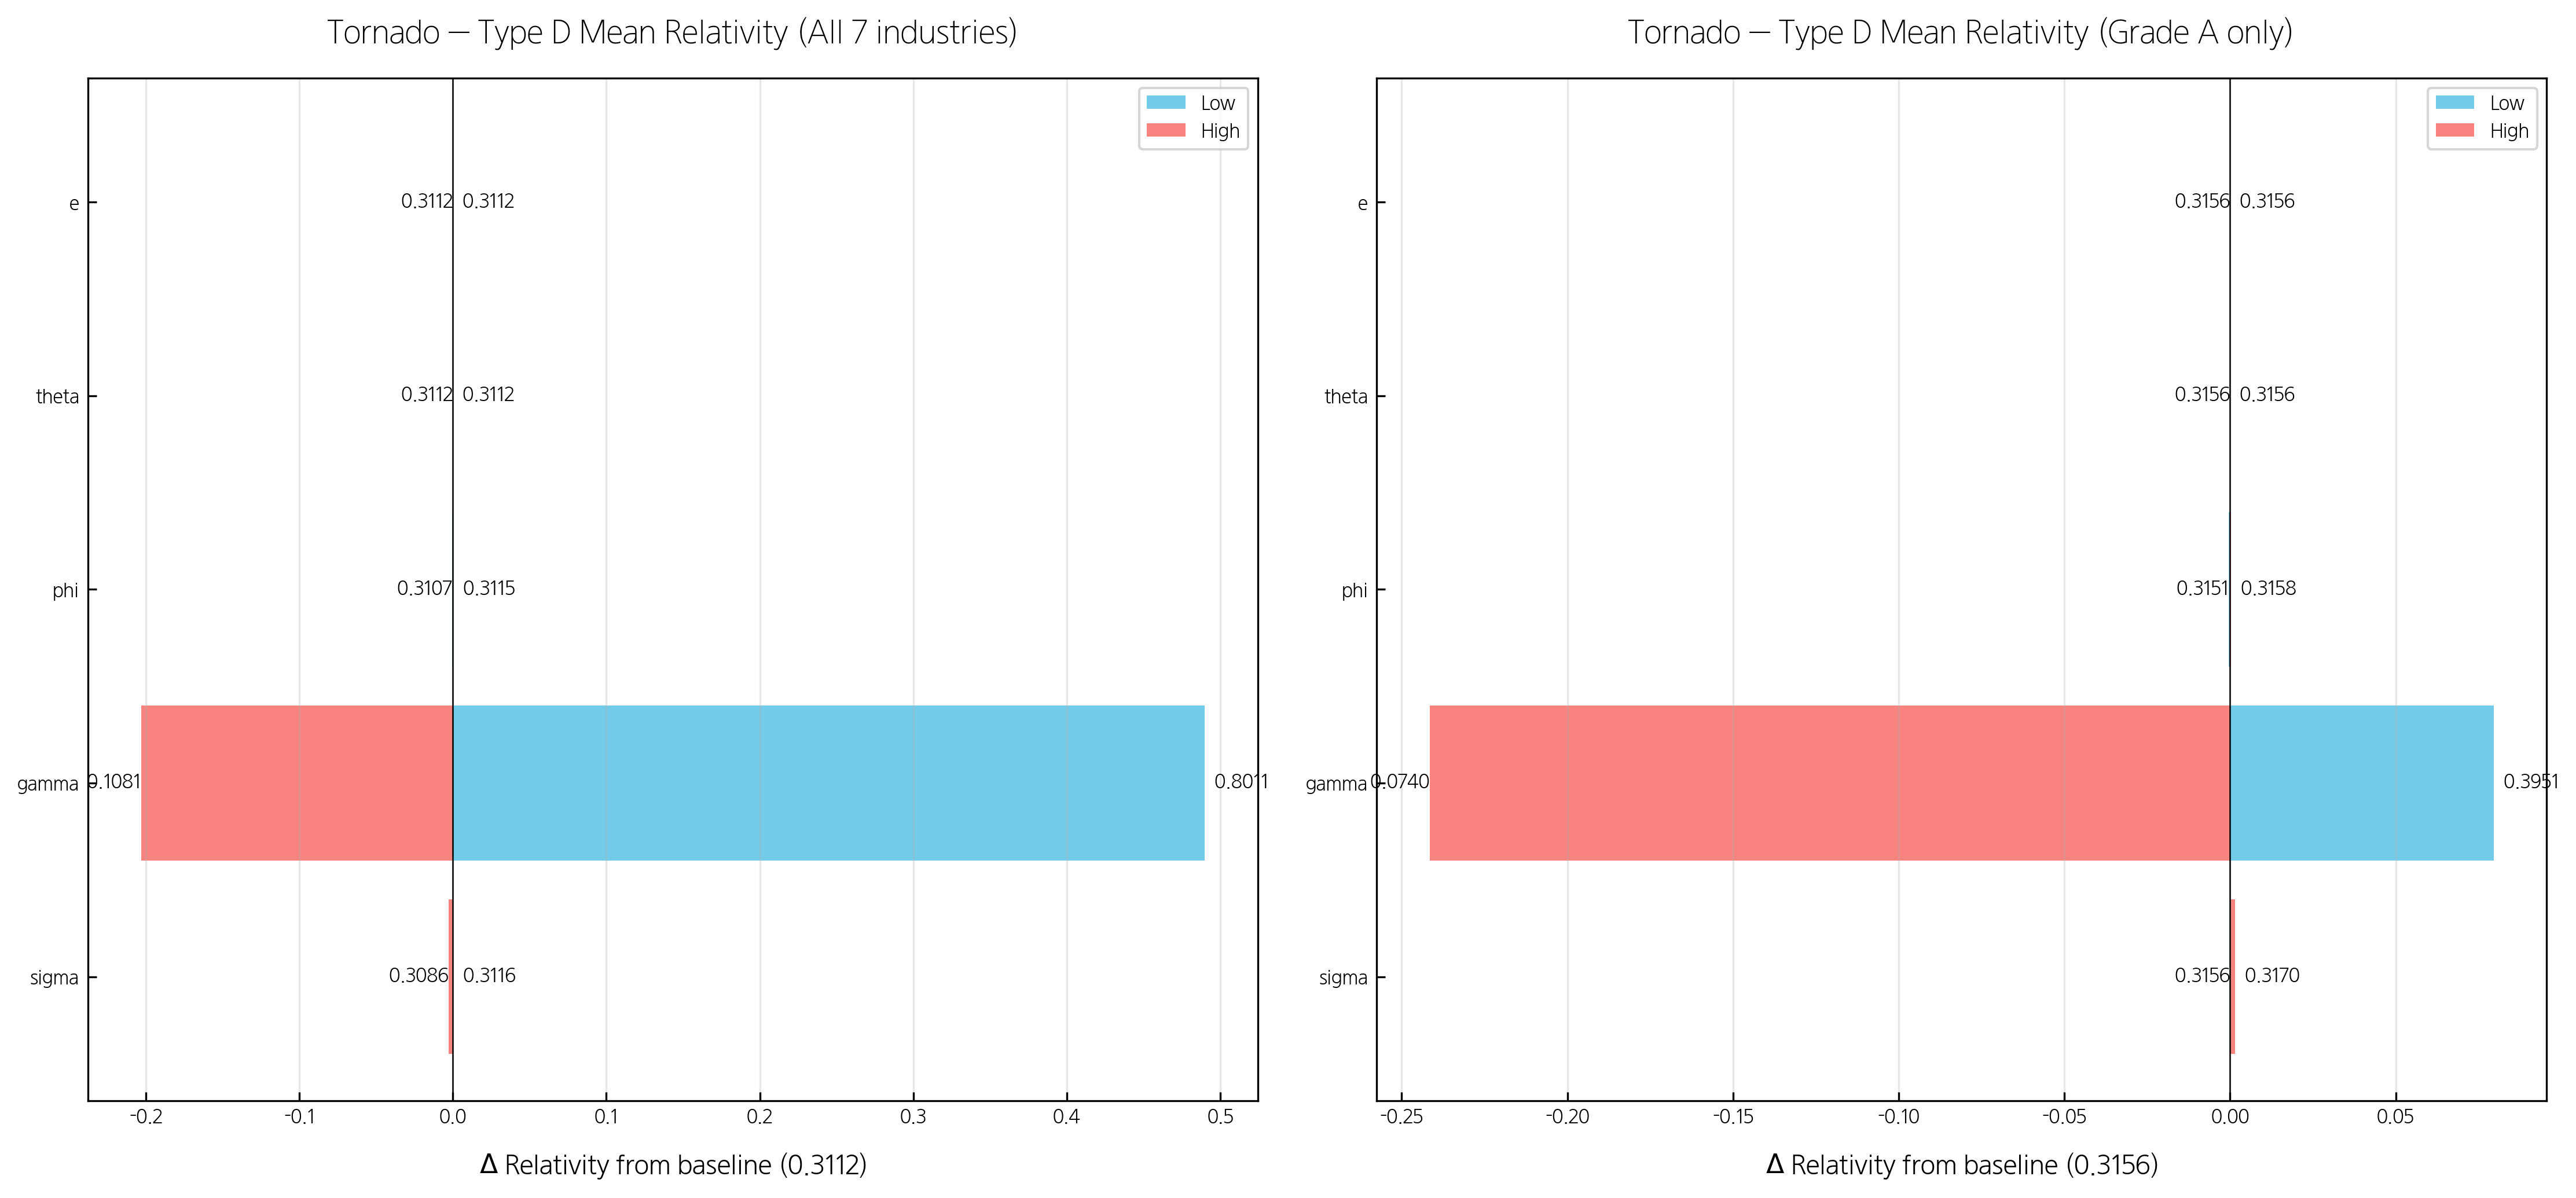

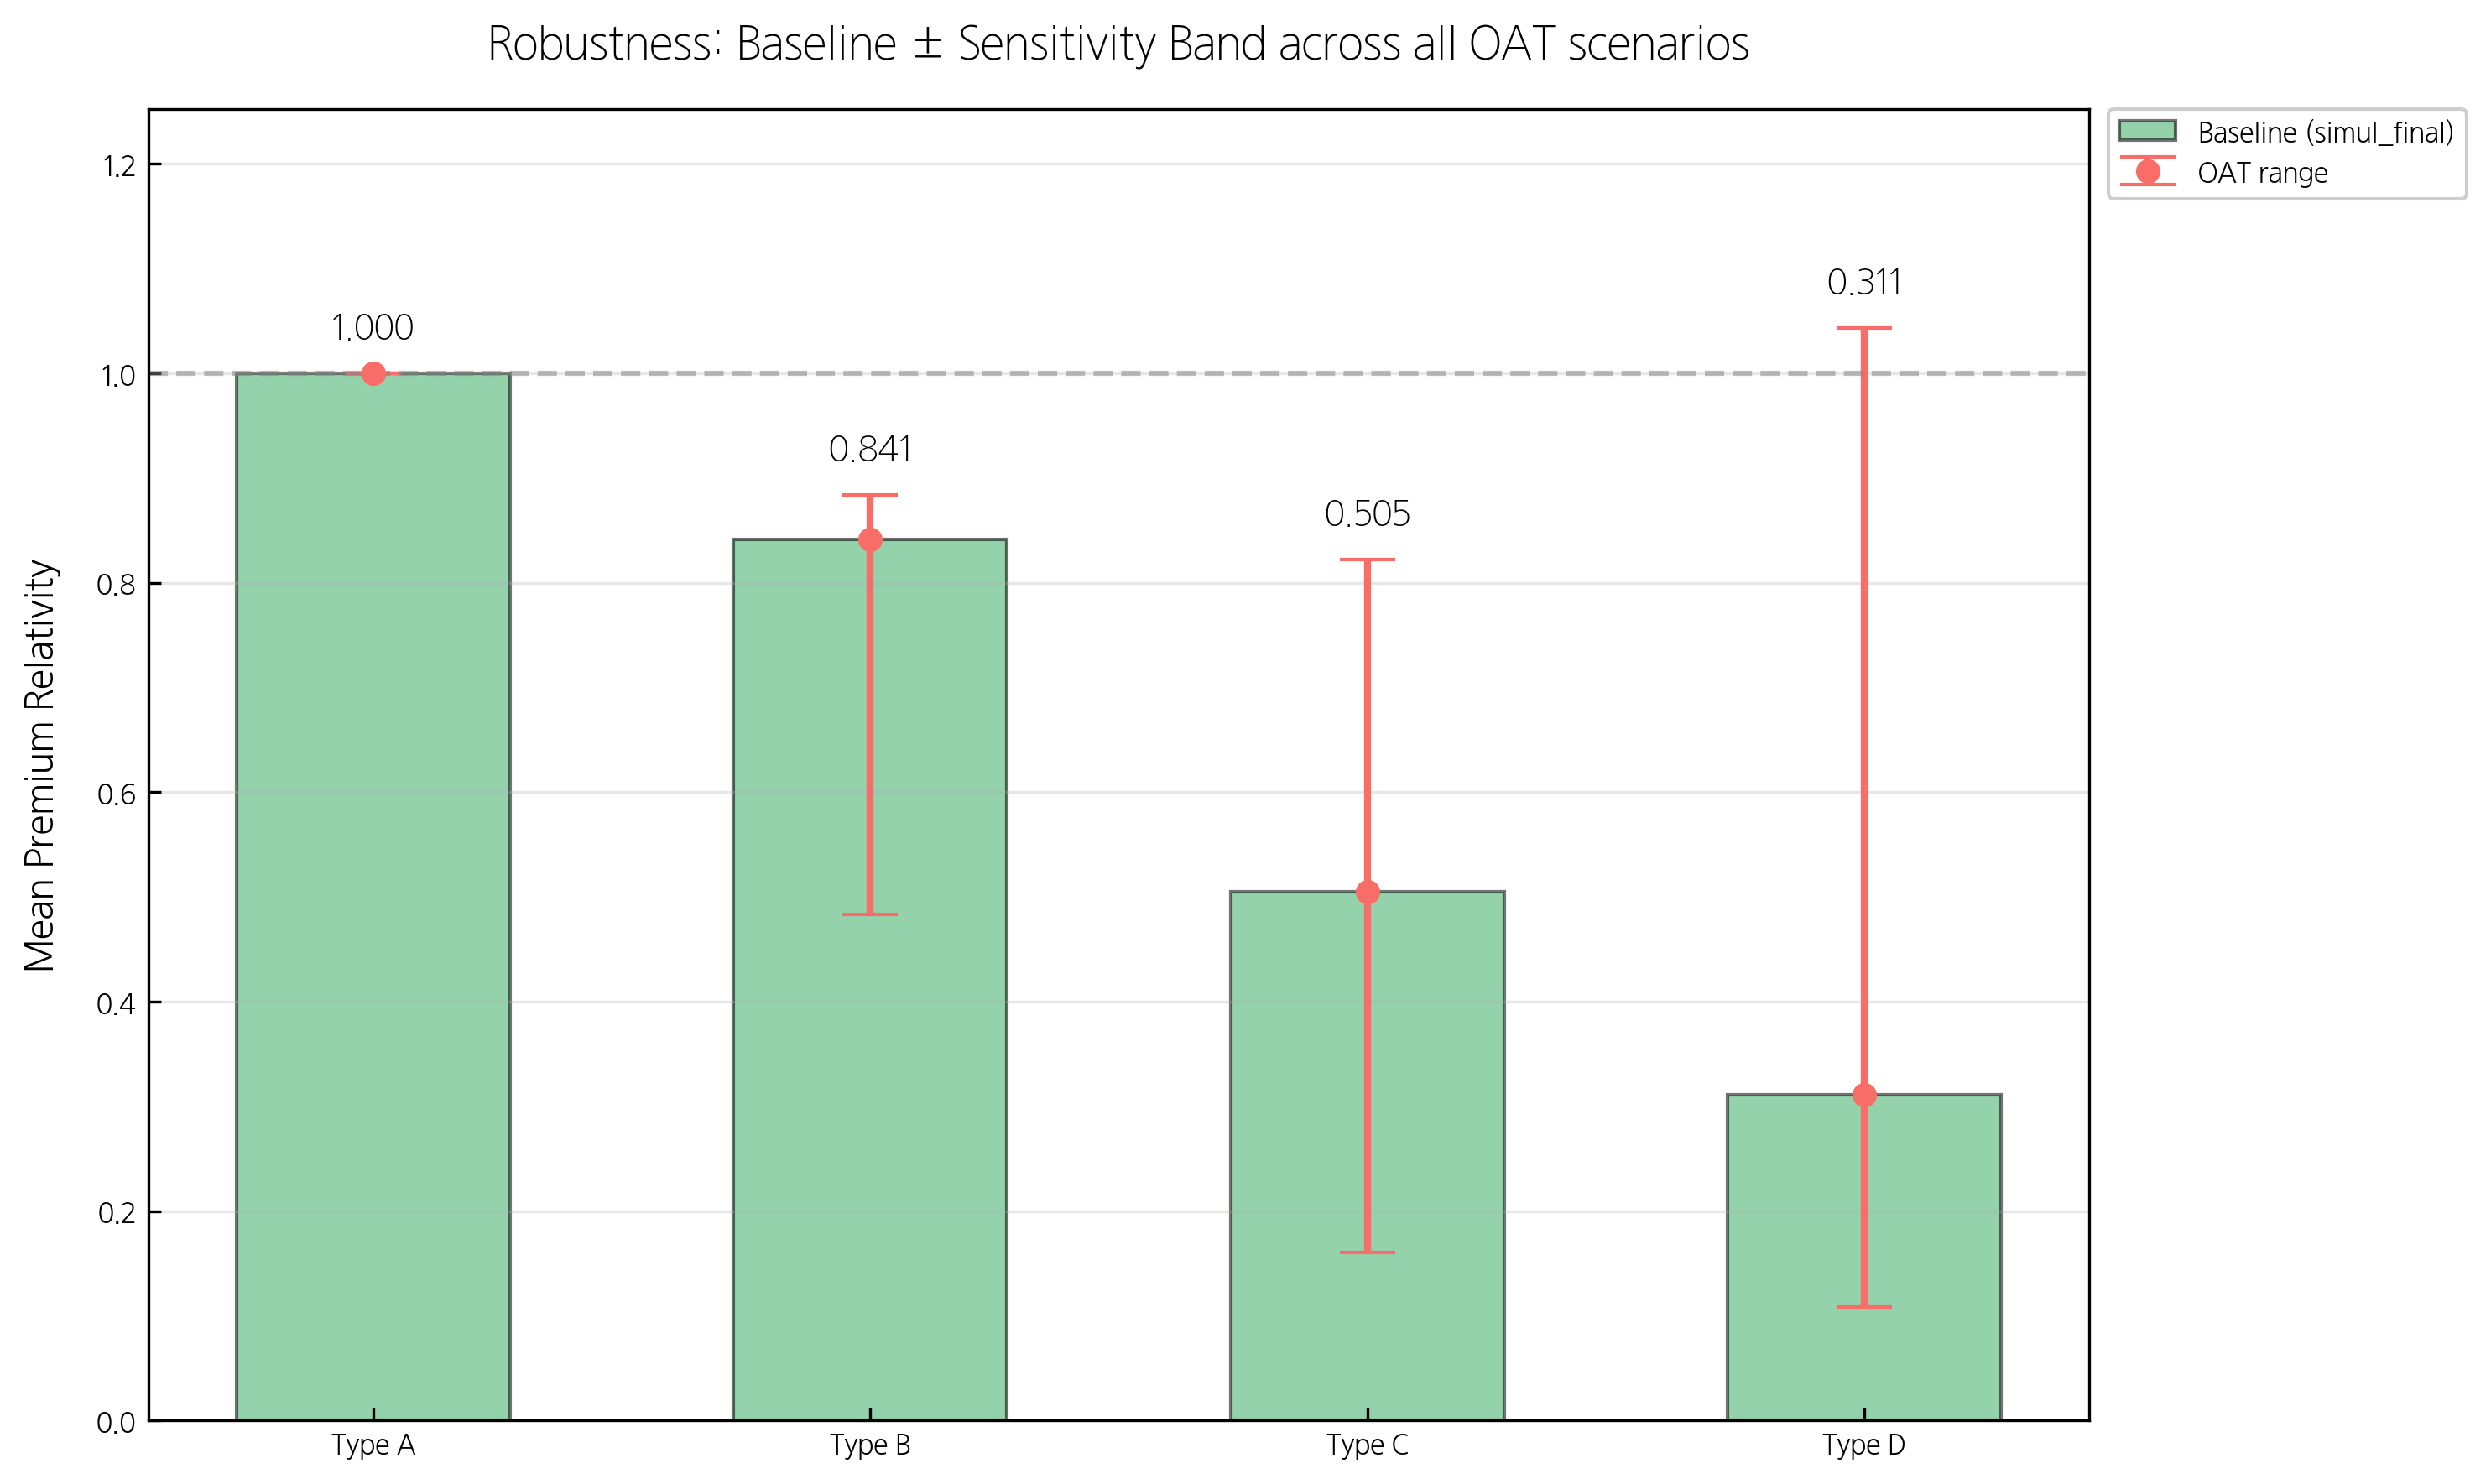

In [8]:
# ─────────────────────────────────────────────
# Visualisation
# ─────────────────────────────────────────────

# Plot 1 — Tornado plots (All 7 industries  +  Grade-A only)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=300)

baseline_d_all = all_results['baseline']['avg_all']['Type D']
baseline_d_a   = all_results['baseline']['avg_A']['Type D']
params       = list(RANGES.keys())
param_labels = [p.replace('expense_ratio', 'e') for p in params]
y_pos        = np.arange(len(params))

# Panel A — All 7 industries
ax = axes[0]
low_vals  = [all_results[f'{p}_low']['avg_all']['Type D']  - baseline_d_all for p in params]
high_vals = [all_results[f'{p}_high']['avg_all']['Type D'] - baseline_d_all for p in params]
ax.barh(y_pos, low_vals,  color=colors[0], alpha=0.85, label='Low')
ax.barh(y_pos, high_vals, color=colors[7], alpha=0.85, label='High')
ax.axvline(x=0, color='black', linewidth=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(param_labels)
ax.set_xlabel(rf'$\Delta$ Relativity from baseline ({baseline_d_all:.4f})')
ax.set_title('Tornado — Type D Mean Relativity (All 7 industries)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
for i, (l, h) in enumerate(zip(low_vals, high_vals)):
    ax.text(l, i, f'  {baseline_d_all + l:.4f}',
            va='center', ha='right' if l < 0 else 'left', fontsize=8)
    ax.text(h, i, f'  {baseline_d_all + h:.4f}',
            va='center', ha='left' if h > 0 else 'right', fontsize=8)

# Panel B — Grade-A industries
ax = axes[1]
low_vals_a  = [all_results[f'{p}_low']['avg_A']['Type D']  - baseline_d_a for p in params]
high_vals_a = [all_results[f'{p}_high']['avg_A']['Type D'] - baseline_d_a for p in params]
ax.barh(y_pos, low_vals_a,  color=colors[0], alpha=0.85, label='Low')
ax.barh(y_pos, high_vals_a, color=colors[7], alpha=0.85, label='High')
ax.axvline(x=0, color='black', linewidth=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(param_labels)
ax.set_xlabel(rf'$\Delta$ Relativity from baseline ({baseline_d_a:.4f})')
ax.set_title('Tornado — Type D Mean Relativity (Grade A only)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
for i, (l, h) in enumerate(zip(low_vals_a, high_vals_a)):
    ax.text(l, i, f'  {baseline_d_a + l:.4f}',
            va='center', ha='right' if l < 0 else 'left', fontsize=8)
    ax.text(h, i, f'  {baseline_d_a + h:.4f}',
            va='center', ha='left' if h > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig("figures/sensitivity_tornado.png", dpi=300, bbox_inches='tight')
plt.show()


# Plot 2 — Baseline ± sensitivity band across all OAT scenarios
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
x_pos = np.arange(len(type_order))

baseline_vals = [all_results['baseline']['avg_all'][t] for t in type_order]
ax.bar(x_pos, baseline_vals, width=0.55,
       color=colors[4], alpha=0.55, edgecolor='black',
       label='Baseline (simul_final)')

# Track each Type's upper-cap y-coordinate so labels can sit above the error bar
upper_caps = []
for i, t in enumerate(type_order):
    vals = [all_results[k]['avg_all'][t] for k in all_results]
    yerr_lo = baseline_vals[i] - min(vals)
    yerr_hi = max(vals) - baseline_vals[i]
    ax.errorbar(i, baseline_vals[i],
                yerr=[[yerr_lo], [yerr_hi]],
                fmt='o', color=colors[7], capsize=8, linewidth=2,
                label='OAT range' if i == 0 else None)
    upper_caps.append(baseline_vals[i] + yerr_hi)

# Headroom above the highest upper cap, plus a fixed label offset
ymax_data = max(upper_caps + [1.0])
ax.set_ylim(0, ymax_data * 1.20)
label_dy = ymax_data * 0.025

ax.set_xticks(x_pos)
ax.set_xticklabels(type_order)
ax.set_ylabel('Mean Premium Relativity')
ax.set_title('Robustness: Baseline ± Sensitivity Band across all OAT scenarios',
             fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
# Park the legend outside the axes so it never overlaps labels or error bars
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0),
          framealpha=0.95, borderaxespad=0.)
ax.grid(True, alpha=0.3, axis='y')

# Place each baseline value above its own upper error-bar cap
for i, v in enumerate(baseline_vals):
    ax.text(i, upper_caps[i] + label_dy, f'{v:.3f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("figures/sensitivity_robustness_bars.png", dpi=300, bbox_inches='tight')
plt.show()
